### Example: Training a Simple Classification Model
This example demonstrates the basic ML workflow: data preparation, vectorization, training, and prediction.

# Football Corporate Intelligence — v13

**Financing and Capital Markets: Benfica SAD, FC Porto SAD and Sporting SAD (2019–2025)**

**Project output folder:** `MyDrive/Colab Notebooks/projeto_nlp/v13`

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Dados de exemplo (Frases e seus rótulos: 1=Financiamento, 0=Outros)
frases = [
    "Benfica SAD lança emissão de obrigações",
    "Sporting SAD anuncia aumento de capital",
    "O sol brilha intensamente hoje",
    "Porto SAD renegocia dívida bancária",
    "A equipa de futebol treinou de manhã"
]
y = [1, 1, 0, 1, 0]

# 2. Vetorização (Transformar texto em números)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(frases)

# 3. Treinar o Modelo (Regressão Logística)
modelo_simples = LogisticRegression()
modelo_simples.fit(X, y)

# 4. Testar com uma nova frase
nova_frase = ["SAD prepara novo empréstimo obrigacionista"]
X_new = vectorizer.transform(nova_frase)
previsao = modelo_simples.predict(X_new)

print(f"Frase: {nova_frase[0]}")
print(f"Previsão (1=Relevante, 0=Não): {previsao[0]}")

Frase: SAD prepara novo empréstimo obrigacionista
Previsão (1=Relevante, 0=Não): 1


### Project objective

The objective is to identify financing-related archived news about Portugal’s three largest football SADs, classify the financing mechanism, extract key financial information and analyse differences across clubs, years and sources.

## How to run the notebook

Execute the notebook from top to bottom. It will:

- create a fresh v13 project structure in Google Drive;
- collect resumable raw files separately by club, source and year;
- use broad club queries plus focused financing queries to improve positive-example recall;
- audit source and year coverage without imposing a mandatory source minimum;
- generate a diverse human-annotation template and preserve existing human labels;
- normalise and deduplicate human labels before modelling;
- use a stratified 80/20 train–test split;
- infer labels for the unannotated corpus while always giving precedence to human-validated labels.

Collection and annotation targets are advisory quality goals. The notebook reports shortfalls instead of pretending that archive coverage is complete.

# **1 - Startup (always run first)**

## 1.1 — Project folders and dependencies

In [6]:
import sys
import subprocess
import importlib.util
import os

print("Python:", sys.version.split()[0])

DEPENDENCIAS = {
    "pyarrow": "pyarrow",
    "spacy": "spacy",
}

for modulo, pacote in DEPENDENCIAS.items():
    if importlib.util.find_spec(modulo) is None:
        print("A instalar:", pacote)
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pacote],
            check=True,
        )

# ---------------------------------------------------------------------
# Google Drive and v13 folders
# ---------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    RAIZ = (
        "/content/drive/MyDrive/Colab Notebooks/"
        "projeto_nlp/v13"
    )
except ImportError:
    RAIZ = "projeto_nlp/v13"

PASTA_RAW = os.path.join(RAIZ, "raw")
PASTA_TEXTOS = os.path.join(RAIZ, "textos")
PASTA_LOGS = os.path.join(RAIZ, "logs")
PASTA_RESULTADOS = os.path.join(RAIZ, "resultados")
PASTA_MODELOS = os.path.join(RAIZ, "modelos")
PASTA_ANOTACAO = os.path.join(RAIZ, "anotacao")

for pasta in (
    RAIZ,
    PASTA_RAW,
    PASTA_TEXTOS,
    PASTA_LOGS,
    PASTA_RESULTADOS,
    PASTA_MODELOS,
    PASTA_ANOTACAO,
):
    os.makedirs(pasta, exist_ok=True)

CAMINHO_TEMPLATE_ANOTACAO = os.path.join(
    PASTA_ANOTACAO,
    "para_anotar_template.csv",
)
CAMINHO_ANOTACAO_HUMANA = os.path.join(
    PASTA_ANOTACAO,
    "para_anotar_humano.csv",
)
# Optional: place an older human-labelled CSV here to reuse validated labels.
CAMINHO_ANOTACAO_IMPORTADA = os.path.join(
    PASTA_ANOTACAO,
    "anotacoes_legadas_importadas.csv",
)

README_EXECUCAO = os.path.join(RAIZ, "README_EXECUCAO.txt")
with open(README_EXECUCAO, "w", encoding="utf-8") as ficheiro:
    ficheiro.write(
        "Football Corporate Intelligence v13\n"
        "Executar o notebook de cima para baixo.\n"
        "A recolha é separada por clube, fonte e ano e pode ser retomada.\n"
        "Preencher anotacao/para_anotar_humano.csv.\n"
        "Para reutilizar rótulos antigos, copiar o CSV para "
        "anotacao/anotacoes_legadas_importadas.csv.\n"
    )

print("Pasta principal:", RAIZ)
print("Pasta de anotação:", PASTA_ANOTACAO)
print("Importação opcional:", CAMINHO_ANOTACAO_IMPORTADA)

Python: 3.12.13
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta principal: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13
Pasta de anotação: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao
Importação opcional: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/anotacoes_legadas_importadas.csv


The startup cells mount Google Drive, create the project folders and define the study period, sources and club-name variants.

## 1.2 — Study configuration and approved sources

In [69]:
import requests
import time
import json
import re
import os
import hashlib
import collections
import random
import unicodedata
from urllib.parse import urlsplit, unquote
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://arquivo.pt/textsearch"
HDR = {"User-Agent": "PBS-NLP-2026-academic-project"}
PAUSA = 1.0
MAX_TENTATIVAS = 5

# --- Closed study window ---------------------------------------------
ANO_INICIO = 2019
ANO_FINAL = 2020
DE = f"{ANO_INICIO}0101000000"
ATE = f"{ANO_FINAL}1231235959"

Q_TESTE = '"Benfica SAD"'

# --- Advisory quality targets ---------------------------------------
# These are targets for audit and sampling, not mandatory source thresholds.
ALVO_DOCUMENTOS_CORPUS = 1500
ALVO_ANOTACOES_HUMANAS = 300
ALVO_POSITIVOS_HUMANOS = 80
ALVO_FONTES_DIVERSAS = 6
ALVO_EXEMPLOS_POR_FONTE = 5

# --- Single approved source policy -----------------------------------
# This is the only independently maintained source dictionary.
FONTES_FINAIS = {
    # journalistic sources used to build the classification corpus
    "observador": ["observador.pt", "www.observador.pt"],
    "negocios": ["www.jornaldenegocios.pt", "jornaldenegocios.pt"],
    "publico": ["www.publico.pt", "publico.pt"],
    "record": ["www.record.pt", "record.pt", "liga.record.pt"],
    "abola": ["www.abola.pt", "abola.pt"],
    "ojogo": ["www.ojogo.pt", "ojogo.pt"],
    "maisfutebol": ["maisfutebol.iol.pt", "www.maisfutebol.iol.pt"],

    # primary sources retained only for source-policy completeness
    "slbenfica": [
        "www.slbenfica.pt", "slbenfica.pt",
        "media.slbenfica.pt", "m.slbenfica.pt",
    ],
    "fcporto": ["www.fcporto.pt", "fcporto.pt"],
    "sporting": ["www.sporting.pt", "sporting.pt"],
    "euronext": ["www.euronext.com", "euronext.com"],
}

NOMES_FONTES_NOTICIOSAS = [
    "observador", "negocios", "publico", "record",
    "abola", "ojogo", "maisfutebol",
]
NOMES_FONTES_PRIMARIAS = [
    "slbenfica", "fcporto", "sporting", "euronext",
]

FONTES_NOTICIOSAS = {
    nome: FONTES_FINAIS[nome]
    for nome in NOMES_FONTES_NOTICIOSAS
}
FONTES_PRIMARIAS = {
    nome: FONTES_FINAIS[nome]
    for nome in NOMES_FONTES_PRIMARIAS
}

# Backwards-compatible aliases. They are derived, never edited separately.
NOTICIOSAS = FONTES_NOTICIOSAS
PRIMARIAS = FONTES_PRIMARIAS

HOSTS_NOTICIOSOS = [
    host for hosts in FONTES_NOTICIOSAS.values() for host in hosts
]
HOTS_PRIMARIOS = [
    host for hosts in FONTES_PRIMARIAS.values() for host in hosts
]
TODOS_HOSTS = HOSTS_NOTICIOSOS + HOSTS_PRIMARIOS

if len(TODOS_HOSTS) != len(set(TODOS_HOSTS)):
    duplicados = sorted({h for h in TODOS_HOSTS if TODOS_HOSTS.count(h) > 1})
    raise RuntimeError(f"Hosts repetidos entre fontes: {duplicados}")

# --- Name variants ----------------------------------------------------
VARIANTES = {
    "benfica": [
        '"Benfica SAD"', '"Benfica, SAD"', '"Benfica - Futebol SAD"',
    ],
    "porto": [
        '"FC Porto SAD"', '"Porto SAD"', '"FC Porto, SAD"',
        '"Porto, SAD"', '"F.C. Porto SAD"',
    ],
    "sporting": [
        '"Sporting SAD"', '"Sporting, SAD"',
        '"Sporting - Futebol SAD"',
    ],
}

VARIANTES_REG = {
    "benfica": ['"Sport Lisboa e Benfica - Futebol SAD"'],
    "porto": ['"Futebol Clube do Porto - Futebol SAD"'],
    "sporting": ['"Sporting Clube de Portugal - Futebol SAD"'],
}

SESSAO = requests.Session()
SESSAO.headers.update(HDR)

print("Período global:", DE, "a", ATE)
print("Fontes noticiosas:", list(FONTES_NOTICIOSAS))
print("Fontes primárias:", list(FONTES_PRIMARIAS))
print("Hosts noticiosos:", len(HOSTS_NOTICIOSOS))
print("Hosts primários:", len(HOSTS_PRIMARIOS))

VERSAO_PIPELINE = "v13"

CONFIGURACAO_EXECUCAO = {
    "versao": VERSAO_PIPELINE,
    "ano_inicio": ANO_INICIO,
    "ano_final": ANO_FINAL,
    "fontes_finais": FONTES_FINAIS,
    "fontes_noticiosas": NOMES_FONTES_NOTICIOSAS,
    "fontes_primarias": NOMES_FONTES_PRIMARIAS,
    "alvo_documentos_corpus": ALVO_DOCUMENTOS_CORPUS,
    "alvo_anotacoes_humanas": ALVO_ANOTACOES_HUMANAS,
    "alvo_positivos_humanos": ALVO_POSITIVOS_HUMANOS,
    "alvo_fontes_diversas": ALVO_FONTES_DIVERSAS,
    "alvo_exemplos_por_fonte": ALVO_EXEMPLOS_POR_FONTE,
    "regra_fontes": (
        "maximizar diversidade e reportar cobertura; "
        "não existe mínimo obrigatório de fontes"
    ),
}

with open(
    os.path.join(RAIZ, "config_fontes_aprovadas.json"),
    "w",
    encoding="utf-8",
) as ficheiro:
    json.dump(
        CONFIGURACAO_EXECUCAO,
        ficheiro,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Configuração guardada em:",
    os.path.join(RAIZ, "config_fontes_aprovadas.json"),
)

Período global: 20190101000000 a 20201231235959
Fontes noticiosas: ['observador', 'negocios', 'publico', 'record', 'abola', 'ojogo', 'maisfutebol']
Fontes primárias: ['slbenfica', 'fcporto', 'sporting', 'euronext']
Hosts noticiosos: 15
Hosts primários: 10
Configuração guardada em: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/config_fontes_aprovadas.json


All source lists are derived from `FONTES_FINAIS`. Journalistic sources build the classification corpus. Club websites and Euronext remain listed only for source-policy completeness and are not mandatory inputs to the final workflow.

## 1.3 — Arquivo.pt API functions

The collection functions query one validated host at a time, partition retrieval by year and deduplicate results by original URL.

In [8]:
def api(max_tentativas=MAX_TENTATIVAS, **params):
    """Chamada robusta à API do Arquivo.pt, com retries e backoff."""
    ultimo_erro = None

    for tentativa in range(1, max_tentativas + 1):
        try:
            resposta = SESSAO.get(BASE, params=params, timeout=(10, 90))

            if resposta.status_code == 429:
                espera = int(resposta.headers.get("Retry-After", 60))
                print(f"Rate limit: pausa de {espera} segundos.")
                time.sleep(espera)
                continue

            resposta.raise_for_status()
            return resposta.json()

        except (requests.Timeout, requests.ConnectionError,
                requests.HTTPError, ValueError) as erro:
            ultimo_erro = erro
            if tentativa == max_tentativas:
                break
            espera = min(60, 2 ** tentativa + random.random())
            print(f"Tentativa {tentativa}/{max_tentativas} falhou: "
                  f"{type(erro).__name__}. Nova tentativa em {espera:.1f}s.")
            time.sleep(espera)

        finally:
            time.sleep(PAUSA)

    raise RuntimeError(
        f"Falha na API após {max_tentativas} tentativas."
    ) from ultimo_erro


def contar(q, site=None, de=None, ate=None, tipo=None):
    """Estimativa da API para UM host.

    `type` vai como parâmetro do pedido, nunca dentro da query (configuração da API).
    `site` tem de ser UM host validado; concatenar hosts por vírgula faz a
    API descartar o filtro `type` em silêncio (configuração por host).
    """
    de = de or DE
    ate = ate or ATE
    params = {"q": q, "maxItems": 1, "from": de, "to": ate}
    if site:
        params["siteSearch"] = site
    if tipo:
        params["type"] = tipo

    return api(**params).get("estimated_nr_results", 0)


def contar_hosts(q, hosts, de=None, ate=None, tipo=None):
    """Soma a estimativa sobre uma lista de hosts, um pedido por host.

    Nota: hosts distintos não se sobrepõem, por isso a soma é legítima aqui —
    ao contrário da soma sobre variantes de query (sobreposição entre variantes).
    """
    if isinstance(hosts, str):
        hosts = [hosts]
    return sum(contar(q, h, de, ate, tipo) for h in hosts)


def procurar(q, site=None, de=None, ate=None, tipo=None, limite=500,
             verboso=False):
    """Recolha paginada para UM host, com deduplicação local.

    Configuração da recolha:
      - `dedupValue=500`: o valor por omissão (2) limitava a recolha a
        2 itens por site (decisão #9);
      - dedup local por `originalURL`: o servidor devolve capturas
        repetidas do mesmo URL, 500 itens -> 224 únicos (decisão #10);
      - `offset` avança pelo tamanho PEDIDO, não pelo devolvido.

    LIMITE DO SERVIDOR: `offset + maxItems <= 500` por pesquisa (limite da API).
    Pedir mais de 500 não devolve mais nada — usar `procurar_janelas`.
    """
    de, ate = de or DE, ate or ATE
    vistos, itens, offset = set(), [], 0

    while offset < limite:
        tamanho = min(500, limite - offset)
        params = {
            "q": q, "maxItems": tamanho, "offset": offset,
            "from": de, "to": ate,
            "dedupField": "url", "dedupValue": 500,
        }
        if site:
            params["siteSearch"] = site
        if tipo:
            params["type"] = tipo

        lote = api(**params).get("response_items", [])
        if not lote:
            break

        novos = 0
        for it in lote:
            url = it.get("originalURL")
            if url and url not in vistos:
                vistos.add(url)
                itens.append(it)
                novos += 1

        if verboso:
            print(f"    offset={offset:>4} lote={len(lote):>3} "
                  f"novos={novos:>3} acumulado={len(itens)}")

        offset += tamanho
        if len(lote) < tamanho:
            break

    return itens


def procurar_janelas(q, hosts=None, tipo=None, ano_inicio=None, ano_fim=None,
                     verboso=True):
    """Contorna o teto de 500 resultados por pesquisa (limite da API).

    Cada par (host, ano) é uma pesquisa independente, com o seu próprio teto.
    Deduplica globalmente por `originalURL`.

    Devolve (itens, janelas_saturadas). Uma janela saturada significa que o
    total é um LIMITE INFERIOR: é preciso subdividir por trimestre para
    esse par (host, ano).
    """
    ano_inicio = ano_inicio or ANO_INICIO
    ano_fim = ano_fim or ANO_FINAL
    if hosts is None:
        hosts = [None]
    elif isinstance(hosts, str):
        hosts = [hosts]

    vistos, itens, saturadas = set(), [], []

    for host in hosts:
        n_host = 0
        for ano in range(ano_inicio, ano_fim + 1):
            de, ate = f"{ano}0101000000", f"{ano}1231235959"
            lote = procurar(q, site=host, de=de, ate=ate, tipo=tipo,
                            limite=500)
            if len(lote) >= 500:
                saturadas.append((host, ano))

            for it in lote:
                url = it.get("originalURL")
                if url and url not in vistos:
                    vistos.add(url)
                    itens.append(it)
                    n_host += 1

        if verboso and n_host:
            print(f"    {host or '(sem host)'}: {n_host} novos")

    if saturadas and verboso:
        print(f"    AVISO: janelas saturadas {saturadas[:6]}"
              f"{' ...' if len(saturadas) > 6 else ''} "
              f"— total é limite inferior.")

    return itens, saturadas


This cell defines core functions for interacting with the Arquivo.pt API. The comments clarify their purpose and internal logic:

* **`api(max_tentativas=MAX_TENTATIVAS, **params)`:** This is a robust API call function. Its docstring states that it handles `retries` and `exponential backoff` to manage network failures, rate limits (HTTP 429), and other HTTP errors, ensuring reliable requests.
* **`contar(q, site=None, de=None, ate=None, tipo=None)`:** This function provides an *estimate* of results from the API for a *single* host. Its docstring highlights two key decisions:
 * `type` is passed as a request parameter, not within the query (Decision #8).
 * `site` must be a *single, validated host*; concatenating multiple hosts with commas can cause the API to silently ignore the `type` filter, leading to false counts (Decision #6).
* **`contar_hosts(q, hosts, de=None, ate=None, tipo=None)`:** This function sums the estimated counts across a *list of hosts*, making a separate request for each host. The comment notes that this summation is valid because distinct hosts do not overlap, unlike summing over query variants (Decision #13).
* **`procurar(q, site=None, ..., limite=500, ...)`:** This function performs *paginated collection* for a single host, with local deduplication. Its docstring details several corrections/methodological features:
 * `dedupValue=500`: The default value of 2 limited collection to only 2 items per site (Decision #9); setting it to 500 allows for more comprehensive collection.
 * Local deduplication by `originalURL`: The server often returns repeated captures of the same URL, so local deduplication ensures only unique items are kept (Decision #10).
 * `offset` advances by the *requested size*, not the returned size.
 * Server limit: A crucial point (Decision #11) is that `offset + maxItems <= 500` per search. Requesting more than 500 items will not yield more results, necessitating the use of `procurar_janelas` for larger collections.
* **`procurar_janelas(q, hosts=None, tipo=None, ano_inicio=None, ano_fim=None, verboso=True)`:** This function is designed to circumvent the 500-result server limit (Decision #11) by partitioning searches. Each (host, year) pair is treated as an independent search, with its own limit. It performs global deduplication by `originalURL`. The function returns collected items and a list of `saturadas` (saturated windows), indicating intervals where the 500-result limit was hit. A saturated window means the total count is a *lower bound*, suggesting further subdivision (e.g., by quarter) might be needed.

# **2 — URL canonicalization and article detection**

The pattern `/YYYY/MM/DD/` in the path gives the **publication date** — resolves the limitation of `tstamp` being the capture date, not the publication date. Confirm by source in the next cell.

In [9]:
EXCLUIR = re.compile(
    r"/(programas|tag|tags|autor|author|tema|categoria|category|page)/",
    re.IGNORECASE,
)
SUFIXOS = re.compile(r"/(embed|amp|window\.onload)/?$", re.IGNORECASE)
DATA_URL = re.compile(r"/(\d{4})/(\d{2})/(\d{2})/")
EXTENSOES_NAO_ARTIGO = re.compile(
    r"\.(jpg|jpeg|png|gif|svg|css|js|xml|zip|mp4|mp3)(?:$|\?)",
    re.IGNORECASE,
)


def canonical(url):
    if not url:
        return ""
    parsed = urlsplit(url)
    host = parsed.netloc.lower().removeprefix("www.")
    path = SUFIXOS.sub("/", parsed.path).rstrip("/")
    return f"https://{host}{path}"


def e_artigo(url, mime=None, titulo=None):
    """Heurística orientada a recall; a data no URL deixa de ser obrigatória."""
    url_normalizado = (url or "").lower()
    titulo_normalizado = (titulo or "").strip()

    if not url_normalizado:
        return False
    if EXCLUIR.search(url_normalizado):
        return False
    if EXTENSOES_NAO_ARTIGO.search(url_normalizado):
        return False
    if mime and "html" not in mime.lower():
        return False

    return bool(titulo_normalizado or DATA_URL.search(url_normalizado))


def data_do_url(url):
    match = DATA_URL.search(url or "")
    return (
        f"{match.group(1)}-{match.group(2)}-{match.group(3)}"
        if match else None
    )


def doc_id(url):
    canonico = canonical(url)
    return hashlib.sha1(canonico.encode()).hexdigest()[:16]


# **3 — Collection of archived news**

In [10]:
# RECOLHA — camada 0 (bruto, imutável e retomável).
#
# v13 guarda um ficheiro por (clube, fonte, ano). Um ficheiro só é
# considerado completo quando existe também o respetivo marcador `.done.json`.
# Isto evita que uma execução interrompida faça o notebook saltar anos inteiros.

os.makedirs(PASTA_RAW, exist_ok=True)
CAMINHO_AUDITORIA_RECOLHA = os.path.join(
    PASTA_LOGS,
    "auditoria_recolha.csv",
)

# As consultas gerais dão cobertura e negativos. As consultas financeiras
# aumentam o recall de candidatos positivos nas três categorias do projeto.
TERMOS_RECOLHA_FINANCEIRA = [
    '"empréstimo obrigacionista"',
    '"emissão de obrigações"',
    '"papel comercial"',
    '"financiamento bancário"',
    '"linha de crédito"',
    '"refinanciamento"',
    '"reestruturação da dívida"',
    '"aumento de capital"',
    '"injeção de capital"',
    '"emissão de novas ações"',
]

NOME_PRINCIPAL_RECOLHA = {
    "benfica": '"Benfica SAD"',
    "porto": '"FC Porto SAD"',
    "sporting": '"Sporting SAD"',
}

INCLUIR_CONSULTAS_GERAIS = True
INCLUIR_CONSULTAS_FINANCEIRAS = True


def construir_consultas_recolha(clube):
    consultas = []

    if INCLUIR_CONSULTAS_GERAIS:
        consultas.extend(
            ("geral", variante)
            for variante in VARIANTES[clube]
        )

    if INCLUIR_CONSULTAS_FINANCEIRAS:
        nome = NOME_PRINCIPAL_RECOLHA[clube]
        consultas.extend(
            ("financeira", f"{nome} {termo}")
            for termo in TERMOS_RECOLHA_FINANCEIRA
        )

    # Remove duplicados preservando a ordem.
    vistos = set()
    resultado = []
    for familia, consulta in consultas:
        chave = (familia, consulta)
        if chave not in vistos:
            vistos.add(chave)
            resultado.append(chave)
    return resultado


n_pesquisas = 0
for clube in VARIANTES:
    n_consultas = len(construir_consultas_recolha(clube))
    n_pesquisas += (
        n_consultas
        * sum(len(hosts) for hosts in NOTICIOSAS.values())
        * (ANO_FINAL - ANO_INICIO + 1)
    )

print(
    f"Estimativa: ~{n_pesquisas} pedidos de pesquisa, "
    f"~{n_pesquisas * (PAUSA + 0.7) / 60:.0f} minutos."
)

auditoria_recolha = []

for clube in VARIANTES:
    consultas = construir_consultas_recolha(clube)

    for nome_fonte, hosts in NOTICIOSAS.items():
        for ano in range(ANO_INICIO, ANO_FINAL + 1):
            base_nome = f"{clube}__{nome_fonte}__{ano}"
            destino = os.path.join(PASTA_RAW, f"{base_nome}.jsonl")
            temporario = destino + ".part"
            caminho_estado = os.path.join(
                PASTA_RAW,
                f"{base_nome}.done.json",
            )

            # Só saltar quando o ficheiro e o marcador de conclusão existem.
            if os.path.exists(destino) and os.path.exists(caminho_estado):
                try:
                    with open(caminho_estado, encoding="utf-8") as ficheiro:
                        estado = json.load(ficheiro)
                    auditoria_recolha.append(estado)
                    print("Completo, saltado:", base_nome)
                    continue
                except (OSError, ValueError):
                    print("Marcador inválido; recolha repetida:", base_nome)

            if os.path.exists(temporario):
                os.remove(temporario)

            vistos_url = set()
            n_registos = 0
            n_pedidos = 0
            n_saturadas = 0
            erros = []

            de = f"{ano}0101000000"
            ate = f"{ano}1231235959"

            try:
                with open(temporario, "w", encoding="utf-8") as ficheiro:
                    for host in hosts:
                        for familia, consulta in consultas:
                            n_pedidos += 1
                            try:
                                lote = procurar(
                                    consulta,
                                    site=host,
                                    de=de,
                                    ate=ate,
                                    tipo="html",
                                    limite=500,
                                    verboso=False,
                                )
                            except Exception as erro:
                                erros.append(
                                    f"{host} | {consulta} | "
                                    f"{type(erro).__name__}: {erro}"
                                )
                                continue

                            if len(lote) >= 500:
                                n_saturadas += 1

                            for item in lote:
                                url = item.get("originalURL")
                                if not url or url in vistos_url:
                                    continue

                                vistos_url.add(url)
                                item.update({
                                    "_query": consulta,
                                    "_query_family": familia,
                                    "_fonte": nome_fonte,
                                    "_host": host,
                                    "_clube": clube,
                                    "_ano_pesquisa": ano,
                                    "_tipo_fonte": "noticiosa",
                                    "_saturado": len(lote) >= 500,
                                    "_recolhido_em":
                                        datetime.now(timezone.utc).isoformat(),
                                })
                                ficheiro.write(
                                    json.dumps(
                                        item,
                                        ensure_ascii=False,
                                    ) + "\n"
                                )
                                n_registos += 1

                    ficheiro.flush()

                os.replace(temporario, destino)

                estado = {
                    "clube": clube,
                    "fonte": nome_fonte,
                    "ano": ano,
                    "ficheiro": os.path.basename(destino),
                    "consultas_configuradas": len(consultas),
                    "pedidos_executados": n_pedidos,
                    "registos_unicos": n_registos,
                    "janelas_saturadas": n_saturadas,
                    "n_erros": len(erros),
                    "estado": "complete",
                    "concluido_em": datetime.now(timezone.utc).isoformat(),
                }

                with open(
                    caminho_estado,
                    "w",
                    encoding="utf-8",
                ) as ficheiro:
                    json.dump(
                        estado,
                        ficheiro,
                        ensure_ascii=False,
                        indent=2,
                    )

                auditoria_recolha.append(estado)
                pd.DataFrame(auditoria_recolha).to_csv(
                    CAMINHO_AUDITORIA_RECOLHA,
                    index=False,
                    encoding="utf-8-sig",
                )

                print(
                    f"{clube:>8} | {nome_fonte:<12} | {ano} | "
                    f"{n_registos:>5} URLs | erros={len(erros)}"
                )

                if erros:
                    caminho_erros = os.path.join(
                        PASTA_LOGS,
                        f"erros_{base_nome}.txt",
                    )
                    with open(
                        caminho_erros,
                        "w",
                        encoding="utf-8",
                    ) as ficheiro:
                        ficheiro.write("\n".join(erros))

            except Exception:
                print(
                    "Recolha interrompida; parcial mantido em:",
                    temporario,
                )
                raise

auditoria_recolha = pd.DataFrame(auditoria_recolha)

if not auditoria_recolha.empty:
    auditoria_recolha = (
        auditoria_recolha
        .drop_duplicates(
            subset=["clube", "fonte", "ano"],
            keep="last",
        )
        .sort_values(["clube", "fonte", "ano"])
    )
    auditoria_recolha.to_csv(
        CAMINHO_AUDITORIA_RECOLHA,
        index=False,
        encoding="utf-8-sig",
    )

    matriz_recolha = auditoria_recolha.pivot_table(
        index=["clube", "fonte"],
        columns="ano",
        values="registos_unicos",
        aggfunc="sum",
        fill_value=0,
    )
    display(matriz_recolha)

    total_raw = int(auditoria_recolha["registos_unicos"].sum())
    print("Registos raw reportados:", total_raw)
    if total_raw < ALVO_DOCUMENTOS_CORPUS:
        print(
            "AVISO: a recolha ficou abaixo do alvo indicativo de "
            f"{ALVO_DOCUMENTOS_CORPUS} registos. "
            "Isto pode refletir cobertura real do arquivo; confirme a matriz "
            "por fonte e ano antes de avançar."
        )

Estimativa: ~4305 pedidos de pesquisa, ~122 minutos.
Completo, saltado: benfica__observador__2019
Completo, saltado: benfica__observador__2020
Completo, saltado: benfica__observador__2021
Completo, saltado: benfica__observador__2022
Completo, saltado: benfica__observador__2023
Completo, saltado: benfica__observador__2024
Completo, saltado: benfica__observador__2025
Completo, saltado: benfica__negocios__2019
Completo, saltado: benfica__negocios__2020
Completo, saltado: benfica__negocios__2021
Completo, saltado: benfica__negocios__2022
Completo, saltado: benfica__negocios__2023
Completo, saltado: benfica__negocios__2024
Completo, saltado: benfica__negocios__2025
Completo, saltado: benfica__publico__2019
Completo, saltado: benfica__publico__2020
Completo, saltado: benfica__publico__2021
Completo, saltado: benfica__publico__2022
Completo, saltado: benfica__publico__2023
Completo, saltado: benfica__publico__2024
Completo, saltado: benfica__publico__2025
Completo, saltado: benfica__record__2

ano                   2019  2020  2021  2022  2023  2024  2025
clube    fonte                                                
benfica  abola         286   564     0     0     0     0     0
         maisfutebol   158   365     0     0     0     0     0
         negocios      268   101     0     0     0     0     0
         observador    246   296     2     0     0     0     0
         ojogo         360   400     0     0     0     0     0
         publico        66    87     0     0     0     0     0
         record       1190  1213     0     0     0     0     0
porto    abola          51   394     0     0     0     0     0
         maisfutebol    66   215     0     0     0     0     0
         negocios       24   121     0     0     0     0     0
         observador    252    22     2     0     0     0     0
         ojogo         271   241     0     0     0     0     0
         publico        18    30     0     0     0     0     0
         record        545   559     0     0     0     0     0
sporting abola         482   387     0     0     0     0     0
         maisfutebol   199   258     0     0     0     0     0
         negocios      127    75     0     0     0     0     0
         observador    207    71     2     0     0     0     0
         ojogo         235   209     0     0     0     0     0
         publico        33    37     0     0     0     0     0
         record        584   538     0     0     0     0     0

Registos raw reportados: 11857


In [11]:
import os
import pandas as pd

anos_alvo = [2019, 2020]
verificacao = []

for clube in VARIANTES:
    for fonte in NOTICIOSAS:
        for ano in anos_alvo:
            base = f"{clube}__{fonte}__{ano}"

            raw = os.path.join(PASTA_RAW, f"{base}.jsonl")
            done = os.path.join(PASTA_RAW, f"{base}.done.json")
            parcial = raw + ".part"

            if os.path.exists(raw) and os.path.exists(done):
                estado = "completo"
            elif os.path.exists(parcial):
                estado = "parcial"
            else:
                estado = "em_falta"

            verificacao.append({
                "clube": clube,
                "fonte": fonte,
                "ano": ano,
                "estado": estado,
                "raw_existe": os.path.exists(raw),
                "done_existe": os.path.exists(done),
            })

verificacao = pd.DataFrame(verificacao)

display(
    verificacao.pivot_table(
        index=["clube", "fonte"],
        columns="ano",
        values="estado",
        aggfunc="first",
    )
)

print(verificacao["estado"].value_counts())
print(
    "\nCombinações esperadas:",
    len(VARIANTES) * len(NOTICIOSAS) * len(anos_alvo),
)

em_falta = verificacao[
    verificacao["estado"] != "completo"
]

if em_falta.empty:
    print("\n✅ A Secção 3 está completa para 2019–2020.")
else:
    print("\n⚠️ Combinações ainda incompletas:")
    display(em_falta)

ano                       2019      2020
clube    fonte                          
benfica  abola        completo  completo
         maisfutebol  completo  completo
         negocios     completo  completo
         observador   completo  completo
         ojogo        completo  completo
         publico      completo  completo
         record       completo  completo
porto    abola        completo  completo
         maisfutebol  completo  completo
         negocios     completo  completo
         observador   completo  completo
         ojogo        completo  completo
         publico      completo  completo
         record       completo  completo
sporting abola        completo  completo
         maisfutebol  completo  completo
         negocios     completo  completo
         observador   completo  completo
         ojogo        completo  completo
         publico      completo  completo
         record       completo  completo

estado
completo    42
Name: count, dtype: int64

Combinações esperadas: 42

✅ A Secção 3 está completa para 2019–2020.


# **4 — Corpus construction**

In [12]:
import os

COLUNAS_REGISTOS = [
    "doc_id",
    "clube_query",
    "fonte",
    "tipo_fonte",
    "query",
    "query_family",
    "host_recolha",
    "ano_pesquisa",
    "url_original",
    "url_canonico",
    "url_arquivo",
    "link_texto",
    "tstamp_captura",
    "mime",
    "data_publicacao",
    "titulo",
    "e_artigo",
]

registos = []
for nome_ficheiro in sorted(os.listdir(PASTA_RAW)):
    if not nome_ficheiro.endswith(".jsonl"):
        continue

    caminho = os.path.join(PASTA_RAW, nome_ficheiro)
    with open(caminho, encoding="utf-8") as ficheiro:
        for numero_linha, linha in enumerate(ficheiro, start=1):
            try:
                item = json.loads(linha)
            except json.JSONDecodeError as erro:
                print(
                    f"Linha inválida ignorada: "
                    f"{caminho}:{numero_linha} — {erro}"
                )
                continue

            url = item.get("originalURL", "")
            titulo = item.get("title")
            mime = item.get("mimeType")

            registos.append({
                "doc_id": doc_id(url),
                "clube_query": item.get("_clube"),
                "fonte": item.get("_fonte"),
                "tipo_fonte": item.get("_tipo_fonte"),
                "query": item.get("_query"),
                "query_family": item.get("_query_family", "geral"),
                "host_recolha": item.get("_host"),
                "ano_pesquisa": item.get("_ano_pesquisa"),
                "url_original": url,
                "url_canonico": canonical(url),
                "url_arquivo": item.get("linkToArchive"),
                "link_texto": item.get("linkToExtractedText"),
                "tstamp_captura": item.get("tstamp"),
                "mime": mime,
                "data_publicacao": data_do_url(url),
                "titulo": titulo,
                "e_artigo": e_artigo(
                    url,
                    mime=mime,
                    titulo=titulo,
                ),
            })

bruto = pd.DataFrame(registos, columns=COLUNAS_REGISTOS)

if bruto.empty:
    raise RuntimeError(
        "A recolha não produziu registos. "
        "Confirme as fontes, datas e queries."
    )

fontes_brutas_inesperadas = sorted(
    set(bruto["fonte"].dropna()) - set(FONTES_NOTICIOSAS)
)
if fontes_brutas_inesperadas:
    raise RuntimeError(
        f"Fontes não aprovadas nos ficheiros raw: "
        f"{fontes_brutas_inesperadas}. "
        "Use uma pasta v13 limpa."
    )

print(
    "capturas:",
    len(bruto),
    "| artigos:",
    int(bruto["e_artigo"].sum()),
)

art = bruto.loc[bruto["e_artigo"]].copy()
if art.empty:
    raise RuntimeError(
        "Foram recolhidos registos, mas nenhum passou "
        "a heurística de artigo."
    )

# Keep URL, archive link, extracted-text link and title from the same capture.
art = art.sort_values(["doc_id", "tstamp_captura"])
representante = art.drop_duplicates("doc_id", keep="last").copy()

agregados = (
    art.groupby("doc_id", as_index=False)
    .agg(
        clubes=("clube_query", lambda s: sorted(set(s.dropna()))),
        queries=("query", lambda s: sorted(set(s.dropna()))),
        familias_query=(
            "query_family",
            lambda s: sorted(set(s.dropna())),
        ),
        anos_pesquisa=(
            "ano_pesquisa",
            lambda s: sorted(set(s.dropna())),
        ),
        n_capturas=("doc_id", "size"),
    )
)

colunas_representante = [
    "doc_id",
    "fonte",
    "tipo_fonte",
    "url_original",
    "url_canonico",
    "url_arquivo",
    "link_texto",
    "tstamp_captura",
    "data_publicacao",
    "titulo",
    "mime",
]
corpus = representante[colunas_representante].merge(
    agregados,
    on="doc_id",
    how="left",
    validate="one_to_one",
)

# Validate whether the archive URL embeds the same original URL.
def url_original_embebido(url_arquivo):
    match = re.search(
        r"/wayback/\d+/(https?://.+)$",
        str(url_arquivo or ""),
        flags=re.IGNORECASE,
    )
    return unquote(match.group(1)) if match else ""


corpus["url_embebido_arquivo"] = corpus["url_arquivo"].apply(
    url_original_embebido
)
corpus["par_url_valido"] = (
    corpus["url_embebido_arquivo"].ne("")
    & corpus["url_original"].apply(canonical).eq(
        corpus["url_embebido_arquivo"].apply(canonical)
    )
)

# Human review receives an archive link only when the pair is verified.
corpus["url_para_revisao"] = corpus["url_original"]
mask_arquivo_valido = (
    corpus["par_url_valido"]
    & corpus["url_arquivo"].notna()
)
corpus.loc[
    mask_arquivo_valido,
    "url_para_revisao",
] = corpus.loc[
    mask_arquivo_valido,
    "url_arquivo",
]

problemas_url = corpus.loc[
    corpus["url_arquivo"].notna()
    & corpus["url_arquivo"].astype(str).ne("")
    & ~corpus["par_url_valido"]
].copy()
problemas_url.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "pares_url_para_rever.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

# ---------------------------------------------------------------------
# Date handling
# ---------------------------------------------------------------------
# URL dates are treated as confirmed publication dates. When a URL has no
# date, the archive capture date is retained as a provisional analysis date.
# Section 5 later attempts to recover a publication date from the article text.

def converter_tstamp_captura(valor):
    texto = re.sub(r"\D", "", str(valor or ""))
    if len(texto) < 8:
        return pd.NaT
    formato = "%Y%m%d%H%M%S" if len(texto) >= 14 else "%Y%m%d"
    return pd.to_datetime(
        texto[:14] if len(texto) >= 14 else texto[:8],
        format=formato,
        errors="coerce",
    )


corpus["data_publicacao_dt"] = pd.to_datetime(
    corpus["data_publicacao"],
    errors="coerce",
)
corpus["data_captura_dt"] = corpus[
    "tstamp_captura"
].apply(converter_tstamp_captura)

corpus["data_analise_dt"] = (
    corpus["data_publicacao_dt"]
    .combine_first(corpus["data_captura_dt"])
)
corpus["origem_data"] = "sem_data"
corpus.loc[
    corpus["data_captura_dt"].notna(),
    "origem_data",
] = "captura_arquivo"
corpus.loc[
    corpus["data_publicacao_dt"].notna(),
    "origem_data",
] = "url"

corpus["data_publicacao_confirmada"] = (
    corpus["data_publicacao_dt"].notna()
)
corpus["ano_publicacao"] = (
    corpus["data_publicacao_dt"].dt.year
)
corpus["ano_analise"] = corpus["data_analise_dt"].dt.year
corpus["data_analise"] = (
    corpus["data_analise_dt"].dt.strftime("%Y-%m-%d")
)

documentos_sem_data = corpus.loc[
    corpus["data_analise_dt"].isna()
].copy()
documentos_fora_periodo = corpus.loc[
    corpus["data_analise_dt"].notna()
    & ~corpus["ano_analise"].between(
        ANO_INICIO,
        ANO_FINAL,
        inclusive="both",
    )
].copy()

documentos_sem_data.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "documentos_sem_data_publicacao.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)
documentos_fora_periodo.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "documentos_fora_periodo.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

corpus = corpus.loc[
    corpus["ano_analise"].between(
        ANO_INICIO,
        ANO_FINAL,
        inclusive="both",
    )
].copy()

if corpus.empty:
    raise RuntimeError(
        "Nenhum documento com data de URL ou captura entre "
        f"{ANO_INICIO} e {ANO_FINAL}."
    )

print(
    "Documentos sem qualquer data excluídos:",
    len(documentos_sem_data),
)
print(
    "Documentos fora do período excluídos:",
    len(documentos_fora_periodo),
)

fontes_corpus_inesperadas = sorted(
    set(corpus["fonte"].dropna()) - set(FONTES_NOTICIOSAS)
)
if fontes_corpus_inesperadas:
    raise RuntimeError(
        f"Fontes não aprovadas no corpus: "
        f"{fontes_corpus_inesperadas}"
    )

print(
    "artigos únicos:",
    len(corpus),
    "| taxa de duplicação:",
    round(1 - len(corpus) / max(len(art), 1), 3),
)
print(
    "Pares arquivo/original não confirmados:",
    len(problemas_url),
)
print("\nDocumentos por fonte:")
print(
    corpus["fonte"]
    .value_counts()
    .reindex(FONTES_NOTICIOSAS, fill_value=0)
)
print("\nDocumentos por ano de análise:")
print(
    corpus["ano_analise"]
    .value_counts()
    .sort_index()
)
print("\nOrigem inicial da data:")
print(corpus["origem_data"].value_counts(dropna=False))

capturas: 11857 | artigos: 11453
Documentos sem qualquer data excluídos: 0
Documentos fora do período excluídos: 75
artigos únicos: 6785 | taxa de duplicação: 0.408
Pares arquivo/original não confirmados: 32

Documentos por fonte:
fonte
observador      770
negocios        438
publico          98
record         1107
abola          1957
ojogo          1538
maisfutebol     877
Name: count, dtype: int64

Documentos por ano de análise:
ano_analise
2019    2996
2020    3784
2021       5
Name: count, dtype: int64

Origem inicial da data:
origem_data
captura_arquivo    6044
url                 741
Name: count, dtype: int64


In [13]:
corpus = corpus[
    corpus["ano_analise"].between(2019, 2020)
].copy()

print(corpus["ano_analise"].value_counts().sort_index())

ano_analise
2019    2996
2020    3784
Name: count, dtype: int64


Layer 1 now preserves the original URL and archive URL from the same capture. Before any link is exported for annotation, the notebook checks that the URL embedded in the Arquivo.pt wayback link canonicalizes to the same original article. Unverified pairs are listed in `resultados/pares_url_para_rever.csv`, and human reviewers receive the original URL instead of a mismatched archive link.

# **5 — Text download and cleaning**

In [14]:
CACHE = f"{RAIZ}/textos"
os.makedirs(CACHE, exist_ok=True)


def texto_de(url):
    if not url:
        return None

    try:
        resposta = SESSAO.get(url, timeout=(10, 90))
        resposta.raise_for_status()
        content_type = resposta.headers.get("Content-Type", "").lower()
        texto = resposta.text.strip()

        if not texto:
            return None
        if "text" not in content_type and "json" not in content_type:
            print(f"Conteúdo inesperado: {content_type} — {url}")
            return None
        if texto.lower().startswith("<!doctype html"):
            print(f"Possível página HTML em vez de texto: {url}")
            return None

        return texto

    except requests.RequestException as erro:
        print(f"Falha no texto: {type(erro).__name__} — {url}")
        return None
    finally:
        time.sleep(PAUSA)


def texto_cached(did, url):
    caminho = f"{CACHE}/{did}.txt"

    if os.path.exists(caminho):
        with open(caminho, encoding="utf-8") as ficheiro:
            return ficheiro.read()

    texto = texto_de(url)
    if texto:
        temporario = caminho + ".part"
        with open(temporario, "w", encoding="utf-8") as ficheiro:
            ficheiro.write(texto)
        os.replace(temporario, caminho)

    return texto


def amostra_por_fonte(df, n_total, seed=42):
    """Equal-source sample with top-up when some sources have few rows."""
    if df.empty or n_total <= 0:
        return df.head(0).copy()

    fontes = [
        fonte for fonte in FONTES_NOTICIOSAS
        if fonte in set(df["fonte"].dropna())
    ]
    if not fontes:
        return df.sample(n=min(n_total, len(df)), random_state=seed)

    quota, resto = divmod(n_total, len(fontes))
    selecionadas = []
    usados = set()

    for pos, fonte in enumerate(fontes):
        alvo = quota + int(pos < resto)
        grupo = df.loc[df["fonte"].eq(fonte)]
        parte = grupo.sample(
            n=min(alvo, len(grupo)),
            random_state=seed + pos,
        )
        selecionadas.append(parte)
        usados.update(parte.index)

    amostra = pd.concat(selecionadas) if selecionadas else df.head(0)
    faltam = min(n_total, len(df)) - len(amostra)
    if faltam > 0:
        restantes = df.loc[~df.index.isin(usados)]
        if not restantes.empty:
            amostra = pd.concat([
                amostra,
                restantes.sample(
                    n=min(faltam, len(restantes)),
                    random_state=seed + 1000,
                ),
            ])

    return amostra.sample(frac=1, random_state=seed).reset_index(drop=True)


AMOSTRA = min(105, len(corpus))
sub = amostra_por_fonte(corpus, AMOSTRA, seed=42).copy()
sub["texto"] = [
    texto_cached(did, url)
    for did, url in zip(sub["doc_id"], sub["link_texto"])
]
sub["n_chars"] = sub["texto"].fillna("").str.len()

print("Distribuição da amostra de inspeção por fonte:")
print(sub["fonte"].value_counts().reindex(FONTES_NOTICIOSAS, fill_value=0))
print("em cache:", len([f for f in os.listdir(CACHE) if f.endswith('.txt')]))
print("sem texto:", sub["texto"].isna().sum())
print(sub["n_chars"].describe())
print("% < 800 chars:", round(100 * (sub["n_chars"] < 800).mean(), 1))


Distribuição da amostra de inspeção por fonte:
fonte
observador     15
negocios       15
publico        15
record         15
abola          15
ojogo          15
maisfutebol    15
Name: count, dtype: int64
em cache: 363
sem texto: 1
count      105.000000
mean      7279.285714
std       3696.516512
min          0.000000
25%       4689.000000
50%       6857.000000
75%       9204.000000
max      23291.000000
Name: n_chars, dtype: float64
% < 800 chars: 1.0


In [16]:
from pathlib import Path

def usar_cache_ou_titulo(linha):
    caminho = Path(CACHE) / f"{linha['doc_id']}.txt"

    if caminho.exists():
        try:
            texto = caminho.read_text(
                encoding="utf-8",
                errors="ignore",
            )

            if len(texto.strip()) >= 300:
                return texto
        except Exception:
            pass

    return str(linha.get("titulo", "") or "")


corpus["texto"] = corpus.apply(
    usar_cache_ou_titulo,
    axis=1,
)

corpus["n_chars"] = (
    corpus["texto"]
    .fillna("")
    .str.len()
)

print("Documentos preparados:", len(corpus))
print("Anos:", sorted(corpus["ano_analise"].unique()))

Documentos preparados: 6780
Anos: [np.int32(2019), np.int32(2020)]


## 5.1 — Text cleaning

In [17]:
import html
import re
import unicodedata

def limpar_texto(texto):
    """
    Limpeza conservadora de texto jornalístico.

    Mantém acentos, símbolos monetários, percentagens e pontuação básica,
    porque estes elementos serão necessários em etapas posteriores.
    """
    if texto is None or pd.isna(texto):
        return ""

    texto = str(texto)
    texto = html.unescape(texto)
    texto = unicodedata.normalize("NFKC", texto)
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        texto,
        flags=re.IGNORECASE,
    )
    texto = re.sub(
        r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b",
        " ",
        texto,
    )
    texto = re.sub(
        r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]",
        " ",
        texto,
    )
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r"\n\s*\n+", "\n\n", texto)
    texto = "\n".join(
        linha.strip()
        for linha in texto.splitlines()
        if linha.strip()
    )
    return texto.strip()


if "texto" not in corpus.columns:
    raise RuntimeError(
        "A coluna 'texto' não existe. Execute primeiro o download integral "
        "do corpus, definindo DESCARREGAR_CORPUS_COMPLETO = True."
    )

corpus["texto_limpo"] = corpus["texto"].apply(limpar_texto)
corpus["n_chars_original"] = corpus["texto"].fillna("").str.len()
corpus["n_chars_limpo"] = corpus["texto_limpo"].str.len()

MIN_CHARS_TEXTO = 300
corpus["texto_valido"] = corpus["n_chars_limpo"] >= MIN_CHARS_TEXTO

# ---------------------------------------------------------------------
# Recover publication dates from the beginning of the extracted text.
# URL date remains the preferred source. Text date is second. Archive
# capture date is only a provisional fallback and is clearly flagged.
# ---------------------------------------------------------------------
MESES_PT = {
    "janeiro": 1,
    "fevereiro": 2,
    "março": 3,
    "marco": 3,
    "abril": 4,
    "maio": 5,
    "junho": 6,
    "julho": 7,
    "agosto": 8,
    "setembro": 9,
    "outubro": 10,
    "novembro": 11,
    "dezembro": 12,
}

PADROES_DATA_TEXTO = [
    re.compile(r"\b(20\d{2})[-/](\d{1,2})[-/](\d{1,2})\b"),
    re.compile(r"\b(\d{1,2})[-/](\d{1,2})[-/](20\d{2})\b"),
    re.compile(
        r"\b(\d{1,2})\s+de\s+"
        r"(janeiro|fevereiro|março|marco|abril|maio|junho|julho|"
        r"agosto|setembro|outubro|novembro|dezembro)"
        r"(?:\s+de)?\s+(20\d{2})\b",
        flags=re.IGNORECASE,
    ),
]


def extrair_data_inicio_texto(texto):
    trecho = str(texto or "")[:3000]

    for pos, padrao in enumerate(PADROES_DATA_TEXTO):
        match = padrao.search(trecho)
        if not match:
            continue

        try:
            if pos == 0:
                ano, mes, dia = map(int, match.groups())
            elif pos == 1:
                dia, mes, ano = map(int, match.groups())
            else:
                dia = int(match.group(1))
                mes = MESES_PT[match.group(2).lower()]
                ano = int(match.group(3))

            data = pd.Timestamp(
                year=ano,
                month=mes,
                day=dia,
            )
            if ANO_INICIO <= data.year <= ANO_FINAL:
                return data
        except (ValueError, KeyError):
            continue

    return pd.NaT


corpus["data_publicacao_texto_dt"] = (
    corpus["texto_limpo"]
    .apply(extrair_data_inicio_texto)
)

mask_data_texto = (
    corpus["data_publicacao_dt"].isna()
    & corpus["data_publicacao_texto_dt"].notna()
)
corpus.loc[
    mask_data_texto,
    "data_publicacao_dt",
] = corpus.loc[
    mask_data_texto,
    "data_publicacao_texto_dt",
]
corpus.loc[mask_data_texto, "origem_data"] = "texto"

corpus["data_publicacao_confirmada"] = (
    corpus["data_publicacao_dt"].notna()
)
corpus["data_publicacao"] = (
    corpus["data_publicacao_dt"].dt.strftime("%Y-%m-%d")
)
corpus["ano_publicacao"] = (
    corpus["data_publicacao_dt"].dt.year
)

corpus["data_analise_dt"] = (
    corpus["data_publicacao_dt"]
    .combine_first(corpus["data_captura_dt"])
)
corpus["data_analise"] = (
    corpus["data_analise_dt"].dt.strftime("%Y-%m-%d")
)
corpus["ano_analise"] = corpus["data_analise_dt"].dt.year

corpus = corpus.loc[
    corpus["ano_analise"].between(
        ANO_INICIO,
        ANO_FINAL,
        inclusive="both",
    )
].copy()

auditoria_datas = (
    corpus.groupby(
        ["origem_data", "ano_analise"],
        dropna=False,
    )
    .size()
    .rename("n_documentos")
    .reset_index()
)
auditoria_datas.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "auditoria_origem_datas.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print("Documentos:", len(corpus))
print("Sem texto original:", corpus["texto"].isna().sum())
print("Textos válidos:", int(corpus["texto_valido"].sum()))
print(
    "Textos abaixo do limite:",
    int((~corpus["texto_valido"]).sum()),
)
print("\nOrigem final da data:")
print(corpus["origem_data"].value_counts(dropna=False))
print("\nDatas de publicação confirmadas:")
print(corpus["data_publicacao_confirmada"].value_counts(dropna=False))

display(
    corpus[
        [
            "doc_id",
            "titulo",
            "n_chars_original",
            "n_chars_limpo",
            "texto_valido",
            "data_publicacao",
            "data_analise",
            "origem_data",
        ]
    ].head()
)

Documentos: 6780
Sem texto original: 0
Textos válidos: 392
Textos abaixo do limite: 6388

Origem final da data:
origem_data
captura_arquivo    5891
url                 741
texto               148
Name: count, dtype: int64

Datas de publicação confirmadas:
data_publicacao_confirmada
False    5891
True      889
Name: count, dtype: int64


,doc_id,titulo,n_chars_original,n_chars_limpo,texto_valido,data_publicacao,data_analise,origem_data
0,000770a6eb413754,A BOLA - SAD quer subir cláusula de Gonçalo Ra...,6273,6232,True,2020-09-21,2020-09-21,texto
1,001a97ab72e013e8,Funcionário da federação moçambicana suspenso ...,2586,2585,True,NaN,2019-02-28,captura_arquivo
2,00212cdff2f2ad8d,Rescisão de Rui Vitória com Benfica está ofici...,2374,2373,True,2019-01-04,2019-01-04,texto
3,0022b51b4e28e72f,Belenenses SAD revela que PSP já tem imagens d...,3579,3578,True,2019-12-17,2019-12-17,texto
4,0029c289793b8cdc,"""Após uma exibição negativa na última jornada,...",3312,3311,True,2019-09-15,2019-09-15,texto


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 5.2 — Manual cleaning inspection

In [19]:
amostra_limpeza = corpus[
    corpus["texto_valido"]
].sample(
    n=min(3, corpus["texto_valido"].sum()),
    random_state=42,
)

for _, linha in amostra_limpeza.iterrows():
    print("=" * 100)
    print("TÍTULO:", linha["titulo"])

    print("\nORIGINAL:\n")
    print(linha["texto"][:1500])

    print("\nLIMPO:\n")
    print(linha["texto_limpo"][:1500])


TÍTULO: A BOLA - Leões reagem à decisão do Conselho de Disciplina (Sporting)

ORIGINAL:

A BOLA - Leões reagem à decisão do Conselho de Disciplina (Sporting) ... Login Edição digital Loja d'Abola A Bola TV Login Edição digital Loja d'Abola A Bola TV Leões reagem à decisão do Conselho de Disciplina Sporting 25-10-2019 19:03 Por Redação Por Redação Depois do Conselho de Disciplina da Federação Portuguesa de Futebol (FPF) arquivar a queixa apresentada pelo Sporting quanto à utilização irregular de um jogador por parte do Alverca, na terceira eliminatória da Taça de Portugal (2-0), os leões emitiram um comunicado a reagir à decisão.   O emblema leonino justificou a queixa com «a necessidade de clarificação» por parte do CD e garantiu que vai acatar a decisão. O Sporting termina ainda a parabenizar o Alverca pelo triunfo obtido.   Leia o comunicado na íntegra:   «A Sporting SAD foi hoje notificada da decisão de arquivamento proferida relativamente ao Futebol Clube de Alverca, registando a c

### 5.3 — Save the cleaned corpus

In [20]:
corpus.to_parquet(
    f"{RAIZ}/corpus_limpo.parquet",
    index=False,
)

corpus.to_csv(
    f"{RAIZ}/corpus_limpo.csv",
    index=False,
)

print("Corpus limpo guardado.")


Corpus limpo guardado.


# **6 — Candidate selection and human annotation**

This step is not the classifier and does not create ground truth. It uses a focused financing vocabulary to prioritize documents for human annotation. Generic financial terms are kept as context and hard-negative signals rather than positive relevance triggers.

In [75]:
import collections
import re
import unicodedata

# Termos específicos do âmbito do projeto. Não incluir acrónimos ambíguos
# nem vocabulário financeiro genérico como gatilhos de relevância.
TERMOS_PESQUISA = [
    # Mercado de dívida
    "emissão de obrigações",
    "emissão obrigacionista",
    "empréstimo obrigacionista",
    "oferta de obrigações",
    "subscrição de obrigações",
    "oferta pública de subscrição",
    "papel comercial",
    "commercial paper",

    # Financiamento bancário e reestruturação
    "financiamento bancário",
    "empréstimo bancário",
    "linha de crédito",
    "crédito sindicado",
    "contrato de financiamento",
    "refinanciamento",
    "reestruturação da dívida",
    "renegociação da dívida",
    "reescalonamento da dívida",
    "acordo com credores",
    "adiar pagamento da dívida",
    "adia pagamento da dívida",

    # Aumento de capital
    "aumento de capital",
    "injeção de capital",
    "subscrição de capital",
    "emissão de novas ações",
    "reforço de capital",
]

# Estes termos são apenas contexto ou campos de extração.
# Nunca tornam um documento relevante por si próprios.
TERMOS_CONTEXTO = [
    "Euronext", "ISIN", "prospeto", "prospecto",
    "cupão", "taxa de juro", "spread", "maturidade",
    "reembolso", "amortização", "garantia", "colateral",
    "credores", "custo da dívida",
]

TERMOS_EXTRACAO = [
    "montante", "milhões de euros", "taxa de juro", "spread",
    "maturidade", "reembolso", "amortização", "prazo",
]

def sem_acentos(texto):
    texto = unicodedata.normalize("NFKD", str(texto or "").lower())
    return "".join(c for c in texto if not unicodedata.combining(c))

TERMOS_PESQUISA_N = [sem_acentos(termo) for termo in TERMOS_PESQUISA]
PADROES_PESQUISA_N = [
    re.compile(rf"(?<!\w){re.escape(termo)}(?!\w)")
    for termo in TERMOS_PESQUISA_N
]

def hits(texto):
    normalizado = sem_acentos(texto)
    return [
        TERMOS_PESQUISA[i]
        for i, padrao in enumerate(PADROES_PESQUISA_N)
        if padrao.search(normalizado)
    ]

corpus["hits_url"] = (
    corpus["url_canonico"]
    .fillna("")
    .str.replace("-", " ", regex=False)
    .apply(hits)
)
corpus["hits_titulo"] = corpus["titulo"].fillna("").apply(hits)

# O pré-filtro usa apenas URL/título para selecionar candidatos.
# A decisão final de relevância depende de anotação humana.
corpus["cand_lexical"] = (
    corpus["hits_url"].str.len().gt(0)
    | corpus["hits_titulo"].str.len().gt(0)
)

print(
    "Candidatos por URL/título:",
    int(corpus["cand_lexical"].sum()),
    "/",
    len(corpus),
    f"({100 * corpus['cand_lexical'].mean():.1f}%)",
)

if "sub" in globals() and isinstance(sub, pd.DataFrame) and "texto" in sub.columns:
    sub["hits_texto"] = sub["texto"].fillna("").apply(hits)
    print(
        "Candidatos pelo texto na amostra:",
        round(100 * sub["hits_texto"].str.len().gt(0).mean(), 1),
        "%",
    )
    print(
        collections.Counter(
            termo
            for lista in sub["hits_texto"]
            for termo in lista
        ).most_common(15)
    )


Candidatos por URL/título: 77 / 6780 (1.1%)
Candidatos pelo texto na amostra: 12.4 %
[('empréstimo obrigacionista', 4), ('injeção de capital', 4), ('emissão de obrigações', 3), ('emissão obrigacionista', 3), ('aumento de capital', 2), ('reforço de capital', 1)]


In [ ]:
# Persist the structural corpus and its source-coverage audit.
corpus.to_parquet(f"{RAIZ}/corpus.parquet", index=False)
corpus.to_csv(
    f"{RAIZ}/corpus.csv",
    index=False,
    encoding="utf-8-sig",
)

cobertura_fontes_corpus = (
    corpus["fonte"]
    .value_counts()
    .reindex(FONTES_NOTICIOSAS, fill_value=0)
    .rename_axis("fonte")
    .reset_index(name="n_documentos")
)
cobertura_fontes_corpus.to_csv(
    f"{RAIZ}/resultados/cobertura_fontes_corpus.csv",
    index=False,
    encoding="utf-8-sig",
)

cobertura_ano_fonte = pd.crosstab(
    corpus["fonte"],
    corpus["ano_analise"],
).reindex(FONTES_NOTICIOSAS, fill_value=0)
cobertura_ano_fonte.to_csv(
    f"{RAIZ}/resultados/cobertura_ano_fonte.csv",
    encoding="utf-8-sig",
)

display(cobertura_fontes_corpus)
display(cobertura_ano_fonte)

print("Corpus estrutural guardado.")
if len(corpus) < ALVO_DOCUMENTOS_CORPUS:
    print(
        "AVISO: o corpus limpo ficou abaixo do alvo indicativo de "
        f"{ALVO_DOCUMENTOS_CORPUS} documentos. "
        "Consulte as auditorias por fonte, ano e origem da data."
    )

This section creates two files inside `v13/anotacao`:

- `para_anotar_template.csv`: blank template generated from the current clean corpus;
- `para_anotar_humano.csv`: working copy to be completed by the group.

Sampling actively promotes diversity across every available source and year. The targets for source diversity and examples per source are advisory, not mandatory. Automatic suggestions are used only to construct a useful annotation sample; human fields remain the gold standard.

## 6.1 — Automatic suggestions and diverse human-annotation sampling

The sampler combines likely positives, hard negatives and easy negatives, then balances selections across available sources and years. It reports missing or underrepresented sources without stopping the workflow.

In [76]:
import re
import pandas as pd

# ---------------------------------------------------------
# 1. Padrões lexicais por categoria do âmbito do projeto
# ---------------------------------------------------------

TERMOS_EVENTO = {
    "capital_market_debt": [
        r"\bemiss[aã]o (?:de )?obriga[cç][oõ]es\b",
        r"\bemiss[aã]o obrigacionista\b",
        r"\bempr[eé]stimo obrigacionista\b",
        r"\boferta (?:p[uú]blica )?de obriga[cç][oõ]es\b",
        r"\bsubscri[cç][aã]o de obriga[cç][oõ]es\b",
        r"\boferta p[uú]blica de subscri[cç][aã]o\b",
        r"\bpapel comercial\b",
        r"\bcommercial paper\b",
    ],
    "bank_and_debt_financing": [
        r"\bfinanciamento banc[aá]rio\b",
        r"\bempr[eé]stimo banc[aá]rio\b",
        r"\blinha de cr[eé]dito\b",
        r"\bcr[eé]dito sindicado\b",
        r"\bcontrato de financiamento\b",
        r"\brefinanciamento\b",
        r"\breestrutura[cç][aã]o (?:da )?d[ií]vida\b",
        r"\brenegocia[cç][aã]o (?:da )?d[ií]vida\b",
        r"\breescalonamento (?:da )?d[ií]vida\b",
        r"\bacordo com credores\b",
        r"\badia(?:r)?(?: o)? pagamento (?:da )?d[ií]vida\b",
    ],
    "capital_increase": [
        r"\baumento de capital\b",
        r"\binje[cç][aã]o de capital\b",
        r"\bsubscri[cç][aã]o de capital\b",
        r"\bemiss[aã]o de novas a[cç][oõ]es\b",
        r"\brefor[cç]o de capital\b",
    ],
}

# Compatibilidade com células antigas que usam este nome.
PADROES_EVENTO = TERMOS_EVENTO

PADROES_CONTEXTO_FINANCEIRO = [
    r"\bfinanciamento\b",
    r"\bempr[eé]stimo\b",
    r"\bcr[eé]dito\b",
    r"\bd[ií]vida\b",
    r"\bobriga[cç][oõ]es\b",
    r"\bcapital\b",
    r"\bjuros\b",
    r"\bmaturidade\b",
    r"\breembolso\b",
    r"\bgarantia\b",
]

PADROES_CLUBES = [
    r"\bbenfica(?: sad)?\b",
    r"\bsport lisboa e benfica(?:\s*[-–]\s*futebol sad)?\b",
    r"\bfc porto(?: sad)?\b",
    r"\bporto sad\b",
    r"\bfutebol clube do porto(?:\s*[-–]\s*futebol sad)?\b",
    r"\bsporting(?: sad)?\b",
    r"\bsporting clube de portugal(?:\s*[-–]\s*futebol sad)?\b",
]

PADROES_SAD_EXPLICITA = [
    r"\bbenfica sad\b",
    r"\bfc porto sad\b",
    r"\bporto sad\b",
    r"\bsporting sad\b",
    r"\bfutebol sad\b",
]

def pre_anotar_evento(texto):
    """Cria apenas sugestões para amostragem; não cria ground truth."""
    texto = str(texto or "").lower()

    menciona_clube = any(
        re.search(padrao, texto)
        for padrao in PADROES_CLUBES
    )
    menciona_sad = any(
        re.search(padrao, texto)
        for padrao in PADROES_SAD_EXPLICITA
    )

    pontuacoes = {
        tipo: sum(
            1 for padrao in padroes
            if re.search(padrao, texto)
        )
        for tipo, padroes in TERMOS_EVENTO.items()
    }

    melhor_evento = max(pontuacoes, key=pontuacoes.get)
    melhor_pontuacao = pontuacoes[melhor_evento]

    # Regra estrita: clube/SAD + expressão de evento específica.
    relevante_sugerido = int(menciona_clube and melhor_pontuacao > 0)

    if not relevante_sugerido:
        melhor_evento = ""

    contexto_financeiro = sum(
        1
        for padrao in PADROES_CONTEXTO_FINANCEIRO
        if re.search(padrao, texto)
    )

    return pd.Series({
        "relevante_sugerido": relevante_sugerido,
        "tipo_evento_sugerido": melhor_evento,
        "confianca_sugestao": (
            melhor_pontuacao
            + int(menciona_sad)
            + min(contexto_financeiro, 2)
        ),
        "menciona_clube": int(menciona_clube),
        "menciona_sad": int(menciona_sad),
        "tem_contexto_financeiro": int(contexto_financeiro > 0),
    })

titulo_regras = corpus["titulo"].fillna("").astype(str)

if "texto_limpo" in corpus.columns:
    corpo_regras = corpus["texto_limpo"].fillna("").astype(str)
elif "texto" in corpus.columns:
    corpo_regras = corpus["texto"].fillna("").astype(str)
else:
    corpo_regras = pd.Series("", index=corpus.index)

corpus["texto_para_pre_anotacao"] = (
    titulo_regras + " " + corpo_regras
).str.strip()

sugestoes = corpus["texto_para_pre_anotacao"].apply(pre_anotar_evento)
corpus[sugestoes.columns] = sugestoes

print("Pré-anotação automática concluída — usar apenas para amostragem.")
print(corpus["relevante_sugerido"].value_counts(dropna=False))
print(
    corpus["tipo_evento_sugerido"]
    .replace("", "sem_evento_especifico")
    .value_counts(dropna=False)
)


Pré-anotação automática concluída — usar apenas para amostragem.
relevante_sugerido
0    6674
1     106
Name: count, dtype: int64
tipo_evento_sugerido
sem_evento_especifico      6674
capital_market_debt          89
capital_increase             14
bank_and_debt_financing       3
Name: count, dtype: int64


In [88]:
N_POSITIVOS_ALVO = 120
N_HARD_NEGATIVES_ALVO = 140
N_EASY_NEGATIVES_ALVO = 80

# Only valid-text documents from the study window and approved news sources
# can enter the human-annotation template.
base_amostragem = corpus.copy()

if "texto_valido" in base_amostragem.columns:
    base_amostragem = base_amostragem.loc[
        base_amostragem["texto_valido"].eq(True)
    ].copy()

base_amostragem = base_amostragem.loc[
    base_amostragem["fonte"].isin(FONTES_NOTICIOSAS)
    & base_amostragem["ano_analise"].between(
        ANO_INICIO,
        ANO_FINAL,
        inclusive="both",
    )
    & base_amostragem["url_para_revisao"]
        .fillna("")
        .astype(str)
        .str.len()
        .gt(0)
].copy()

base_amostragem = (
    base_amostragem
    .drop_duplicates(subset=["doc_id"], keep="last")
    .copy()
)

fontes_disponiveis = [
    fonte
    for fonte in FONTES_NOTICIOSAS
    if base_amostragem["fonte"].eq(fonte).any()
]
fontes_sem_documentos = [
    fonte
    for fonte in FONTES_NOTICIOSAS
    if fonte not in fontes_disponiveis
]

print("Fontes disponíveis para amostragem:", fontes_disponiveis)
if fontes_sem_documentos:
    print(
        "AVISO — fontes configuradas sem documentos utilizáveis:",
        fontes_sem_documentos,
    )

positivos = base_amostragem.loc[
    base_amostragem["relevante_sugerido"].eq(1)
].copy()
positivos["tipo_exemplo_sugerido"] = "positive"

hard_negatives = base_amostragem.loc[
    base_amostragem["relevante_sugerido"].eq(0)
    & base_amostragem["menciona_clube"].eq(1)
    & base_amostragem["tem_contexto_financeiro"].eq(1)
].copy()
hard_negatives["tipo_exemplo_sugerido"] = "hard_negative"

easy_negatives = base_amostragem.loc[
    base_amostragem["relevante_sugerido"].eq(0)
    & ~base_amostragem.index.isin(hard_negatives.index)
].copy()
easy_negatives["tipo_exemplo_sugerido"] = "easy_negative"


def amostrar_diverso(df, n_total, seed):
    """
    Round-robin sampling across source-year strata.

    This maximises diversity among available records. It does not impose a
    mandatory number of sources, because archive coverage is an empirical
    property that must be reported rather than fabricated.
    """
    if df.empty or n_total <= 0:
        return df.head(0).copy()

    trabalho = df.copy()
    trabalho["_estrato_amostragem"] = (
        trabalho["fonte"].fillna("sem_fonte").astype(str)
        + "|"
        + trabalho["ano_analise"]
            .fillna(-1)
            .astype(int)
            .astype(str)
    )

    grupos = {}
    for pos, (estrato, grupo) in enumerate(
        trabalho.groupby("_estrato_amostragem", sort=True)
    ):
        grupos[estrato] = (
            grupo
            .sample(frac=1, random_state=seed + pos)
            .index
            .tolist()
        )

    selecionados = []
    chaves = list(grupos)
    rng = random.Random(seed)
    rng.shuffle(chaves)

    while chaves and len(selecionados) < min(n_total, len(trabalho)):
        proximas = []
        for chave in chaves:
            if grupos[chave] and len(selecionados) < n_total:
                selecionados.append(grupos[chave].pop())
            if grupos[chave]:
                proximas.append(chave)
        chaves = proximas

    return (
        trabalho.loc[selecionados]
        .drop(columns=["_estrato_amostragem"])
        .copy()
    )


para_anotar = pd.concat([
    amostrar_diverso(
        positivos,
        N_POSITIVOS_ALVO,
        42,
    ),
    amostrar_diverso(
        hard_negatives,
        N_HARD_NEGATIVES_ALVO,
        142,
    ),
    amostrar_diverso(
        easy_negatives,
        N_EASY_NEGATIVES_ALVO,
        242,
    ),
], ignore_index=False)

para_anotar = para_anotar.loc[
    ~para_anotar.index.duplicated(keep="first")
].copy()

candidatos_todos = pd.concat(
    [positivos, hard_negatives, easy_negatives],
    ignore_index=False,
).loc[
    lambda d: ~d.index.duplicated(keep="first")
].copy()

# Soft top-up target: try to include several examples from every source that
# has usable documents. Failure to reach the target is reported, not blocked.
for pos, fonte in enumerate(fontes_disponiveis):
    atuais = int(para_anotar["fonte"].eq(fonte).sum())
    falta = max(0, ALVO_EXEMPLOS_POR_FONTE - atuais)

    if falta == 0:
        continue

    disponiveis = candidatos_todos.loc[
        candidatos_todos["fonte"].eq(fonte)
        & ~candidatos_todos.index.isin(para_anotar.index)
    ]

    if not disponiveis.empty:
        complemento = amostrar_diverso(
            disponiveis,
            falta,
            500 + pos,
        )
        para_anotar = pd.concat(
            [para_anotar, complemento],
            ignore_index=False,
        )

para_anotar = (
    para_anotar
    .drop_duplicates(subset=["doc_id"], keep="first")
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

fontes_amostra = sorted(
    para_anotar["fonte"].dropna().unique()
)

colunas_exportar = [
    "doc_id",
    "titulo",
    "fonte",
    "data_publicacao",
    "data_analise",
    "origem_data",
    "ano_analise",
    "url_para_revisao",
    "url_original",
    "url_canonico",
    "url_arquivo",
    "par_url_valido",
    "texto_para_pre_anotacao",
    "relevante_sugerido",
    "tipo_evento_sugerido",
    "confianca_sugestao",
    "tipo_exemplo_sugerido",
]
colunas_exportar = [
    coluna
    for coluna in colunas_exportar
    if coluna in para_anotar.columns
]
para_anotar = para_anotar[colunas_exportar].copy()

# Gold-standard fields remain blank until humans complete them.
CAMPOS_HUMANOS = [
    "relevante",
    "tipo_evento",
    "tipo_exemplo",
    "validado_humano",
    "anotador",
    "notas",
]
for coluna in CAMPOS_HUMANOS:
    para_anotar[coluna] = ""

# The blank reference template is always regenerated from the clean v13 corpus.
para_anotar.to_csv(
    CAMINHO_TEMPLATE_ANOTACAO,
    index=False,
    encoding="utf-8-sig",
)

# Update the working file without overwriting existing human work.
if os.path.exists(CAMINHO_ANOTACAO_HUMANA):
    try:
        trabalho_antigo = pd.read_csv(
            CAMINHO_ANOTACAO_HUMANA,
            encoding="utf-8-sig",
        )
    except UnicodeDecodeError:
        trabalho_antigo = pd.read_csv(
            CAMINHO_ANOTACAO_HUMANA,
            encoding="latin1",
        )

    campos_existentes = [
        "doc_id",
        *[
            coluna
            for coluna in CAMPOS_HUMANOS
            if coluna in trabalho_antigo.columns
        ],
    ]
    rotulos_antigos = (
        trabalho_antigo[campos_existentes]
        .drop_duplicates(subset=["doc_id"], keep="last")
    )

    trabalho_atualizado = para_anotar.drop(
        columns=CAMPOS_HUMANOS,
        errors="ignore",
    ).merge(
        rotulos_antigos,
        on="doc_id",
        how="left",
    )

    for coluna in CAMPOS_HUMANOS:
        if coluna not in trabalho_atualizado.columns:
            trabalho_atualizado[coluna] = ""
        trabalho_atualizado[coluna] = (
            trabalho_atualizado[coluna]
            .fillna("")
        )

    # Keep older human rows even when the refreshed sampler did not select
    # them again. Section 7 later keeps only rows that still match the corpus.
    extras_antigos = trabalho_antigo.loc[
        ~trabalho_antigo["doc_id"].astype(str).isin(
            trabalho_atualizado["doc_id"].astype(str)
        )
    ].copy()

    colunas_trabalho = list(
        dict.fromkeys(
            list(trabalho_atualizado.columns)
            + list(extras_antigos.columns)
        )
    )
    trabalho_atualizado = (
        pd.concat(
            [
                trabalho_atualizado.reindex(
                    columns=colunas_trabalho
                ),
                extras_antigos.reindex(
                    columns=colunas_trabalho
                ),
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset=["doc_id"],
            keep="first",
        )
    )

    trabalho_atualizado.to_csv(
        CAMINHO_ANOTACAO_HUMANA,
        index=False,
        encoding="utf-8-sig",
    )
    print(
        "Ficheiro humano atualizado; rótulos e linhas antigas preservados:",
        CAMINHO_ANOTACAO_HUMANA,
    )
else:
    para_anotar.to_csv(
        CAMINHO_ANOTACAO_HUMANA,
        index=False,
        encoding="utf-8-sig",
    )
    print(
        "Cópia de trabalho criada:",
        CAMINHO_ANOTACAO_HUMANA,
    )


with open(
    os.path.join(
        PASTA_ANOTACAO,
        "README_anotacao.txt",
    ),
    "w",
    encoding="utf-8",
) as ficheiro:
    ficheiro.write(
        "1. Não alterar para_anotar_template.csv.\n"
        "2. Preencher para_anotar_humano.csv.\n"
        "3. Completar relevante, tipo_evento, tipo_exemplo, "
        "validado_humano, anotador e notas.\n"
        "4. Procurar diversidade entre fontes, anos e clubes sempre que "
        "existam candidatos adequados.\n"
        "5. Não existe mínimo obrigatório de fontes; qualquer limitação "
        "de cobertura deve ser reportada.\n"
        "6. As sugestões automáticas nunca substituem validação humana.\n"
    )

distribuicao_anotacao = (
    para_anotar.groupby(
        ["fonte", "tipo_exemplo_sugerido"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(FONTES_NOTICIOSAS, fill_value=0)
)
distribuicao_anotacao.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "distribuicao_fontes_para_anotar_humano.csv",
    ),
    encoding="utf-8-sig",
)

distribuicao_ano_fonte_anotacao = pd.crosstab(
    para_anotar["fonte"],
    para_anotar["ano_analise"],
).reindex(FONTES_NOTICIOSAS, fill_value=0)
distribuicao_ano_fonte_anotacao.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "distribuicao_ano_fonte_anotacao.csv",
    ),
    encoding="utf-8-sig",
)

print(f"Template criado com {len(para_anotar)} documentos.")
print(
    "Fontes representadas:",
    len(fontes_amostra),
    fontes_amostra,
)
if len(fontes_amostra) < ALVO_FONTES_DIVERSAS:
    print(
        "AVISO: a amostra contém menos fontes do que o alvo indicativo "
        f"de {ALVO_FONTES_DIVERSAS}. "
        "O notebook continua e regista a limitação."
    )

for fonte in fontes_disponiveis:
    n_fonte = int(para_anotar["fonte"].eq(fonte).sum())
    if n_fonte < ALVO_EXEMPLOS_POR_FONTE:
        print(
            f"AVISO: {fonte} tem apenas {n_fonte} exemplos; "
            f"alvo indicativo={ALVO_EXEMPLOS_POR_FONTE}."
        )

display(distribuicao_anotacao)
display(distribuicao_ano_fonte_anotacao)
print("\nTemplate:", CAMINHO_TEMPLATE_ANOTACAO)
print("Ficheiro a preencher:", CAMINHO_ANOTACAO_HUMANA)
print("As sugestões automáticas não são ground truth.")
display(para_anotar.head(10))

Fontes disponíveis para amostragem: ['observador', 'negocios', 'publico', 'record', 'abola', 'ojogo', 'maisfutebol']
Ficheiro humano atualizado; rótulos e linhas antigas preservados: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/para_anotar_humano.csv
Template criado com 247 documentos.
Fontes representadas: 7 ['abola', 'maisfutebol', 'negocios', 'observador', 'ojogo', 'publico', 'record']


tipo_exemplo_sugerido,easy_negative,hard_negative,positive
fonte,,,
observador,9,26,15
negocios,2,20,14
publico,14,3,1
record,14,19,10
abola,13,25,12
ojogo,14,16,4
maisfutebol,14,2,0


ano_analise,2019,2020
fonte,,
observador,36,14
negocios,23,13
publico,8,10
record,19,24
abola,14,36
ojogo,14,20
maisfutebol,7,9



Template: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/para_anotar_template.csv
Ficheiro a preencher: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/para_anotar_humano.csv
As sugestões automáticas não são ground truth.


,doc_id,titulo,fonte,data_publicacao,data_analise,origem_data,ano_analise,url_para_revisao,url_original,url_canonico,...,relevante_sugerido,tipo_evento_sugerido,confianca_sugestao,tipo_exemplo_sugerido,relevante,tipo_evento,tipo_exemplo,validado_humano,anotador,notas
0,0182e3d60dcc8d39,Tudo sobre: Montepio – Observador,observador,2019-02-26,2019-02-26,texto,2019,https://arquivo.pt/wayback/20190227211731/http...,https://observador.pt/seccao/economia/banca/mo...,https://observador.pt/seccao/economia/banca/mo...,...,1,capital_increase,4,positive,,,,,,
1,6dc475c7865e5a86,No desporto - Jornal Record,record,NaN,2020-04-27,captura_arquivo,2020,https://arquivo.pt/wayback/20200427175601/http...,https://www.record.pt/fora-de-campo/coronaviru...,https://record.pt/fora-de-campo/coronavirus/no...,...,1,capital_market_debt,5,positive,,,,,,
2,0534e66e8bb2eec5,Covid-19: Benfica doa um milhão de euros ao Se...,maisfutebol,NaN,2020-03-21,captura_arquivo,2020,https://arquivo.pt/wayback/20200321200732/http...,https://maisfutebol.iol.pt/liga/coronavirus/co...,https://maisfutebol.iol.pt/liga/coronavirus/co...,...,0,,0,easy_negative,,,,,,
3,e1429ec1f28af40a,Silvério recusou oferta húngara - Académica - ...,record,NaN,2020-09-10,captura_arquivo,2020,https://arquivo.pt/wayback/20200910153906/http...,http://liga.record.pt/futebol/futebol-nacional...,https://liga.record.pt/futebol/futebol-naciona...,...,0,,2,hard_negative,,,,,,
4,00c5bfaf18f8c59d,A BOLA - SAD sem interesse em negociar Florent...,abola,2020-01-28,2020-01-28,texto,2020,https://arquivo.pt/wayback/20200129011402/http...,https://www.abola.pt/nnh/2020-01-28/benfica-sa...,https://abola.pt/nnh/2020-01-28/benfica-sad-se...,...,0,,1,hard_negative,,,,,,
5,08363c39b75b2d0f,A BOLA - Domingos Soares Oliveira: «Dependemos...,abola,2019-09-06,2019-09-06,texto,2019,https://arquivo.pt/wayback/20190907000930/http...,https://www.abola.pt/nnh/Noticias/Ver/804475,https://abola.pt/nnh/Noticias/Ver/804475,...,0,,1,easy_negative,,,,,,
6,028a39372e21b379,Lateral Alex Pinto reforça Farense por quatro ...,observador,2020-08-11,2020-08-11,url,2020,https://arquivo.pt/wayback/20200821033628/http...,https://observador.pt/2020/08/11/lateral-alex-...,https://observador.pt/2020/08/11/lateral-alex-...,...,0,,1,easy_negative,,,,,,
7,03ca9467740e7c84,"De Dyego Sousa a Trincão, passando por Ighalo:...",record,NaN,2020-02-11,captura_arquivo,2020,https://arquivo.pt/wayback/20200211024643/http...,https://www.record.pt/mercado/detalhe/mercado-...,https://record.pt/mercado/detalhe/mercado-a-fe...,...,0,,2,hard_negative,,,,,,
8,08da2359cc97a79b,Centeno: Não há nenhum euro dos contribuintes ...,negocios,NaN,2019-05-31,captura_arquivo,2019,https://arquivo.pt/wayback/20190531201025/http...,https://www.jornaldenegocios.pt/empresas/banca...,https://jornaldenegocios.pt/empresas/banca---f...,...,1,capital_increase,4,positive,,,,,,
9,0598b81b19379a24,"AG da Benfica SAD aprova lucros de 41,7 milhõe...",publico,2020-10-01,2020-10-01,url,2020,https://arquivo.pt/wayback/20201120211031/http...,https://www.publico.pt/2020/10/01/desporto/not...,https://publico.pt/2020/10/01/desporto/noticia...,...,0,,1,easy_negative,,,,,,


In [89]:
from google.colab import data_table

# Alternativa nativa para visualização interativa sem necessidade de autenticação externa
data_table.enable_dataframe_formatter()
display(distribuicao_anotacao)

tipo_exemplo_sugerido,easy_negative,hard_negative,positive
fonte,,,
observador,9,26,15
negocios,2,20,14
publico,14,3,1
record,14,19,10
abola,13,25,12
ojogo,14,16,4
maisfutebol,14,2,0


In [87]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=distribuicao_anotacao)

https://docs.google.com/spreadsheets/d/1eqrOJNOPvbFo2Ox8mOGHywth1lGD3iHh4eeC1zhvBMU/edit#gid=0


In [26]:
from google.colab import data_table

# Ativa a visualização interativa nativa do Colab
data_table.enable_dataframe_formatter()

# Exibe a distribuição por fonte e tipo de exemplo sugerido
display(distribuicao_anotacao)

tipo_exemplo_sugerido,easy_negative,hard_negative,positive
fonte,,,
observador,9,26,15
negocios,2,20,14
publico,13,3,1
record,14,19,10
abola,14,25,12
ojogo,14,16,5
maisfutebol,14,2,0


# **7 — Binary relevance classification**

This section trains one supervised model:

- `0`: not relevant to a financing event involving one of the selected SADs;
- `1`: relevant to a financing event involving one of the selected SADs.

Only explicitly human-validated labels from `v13/anotacao/para_anotar_humano.csv` and the optional imported legacy file are used. Labels are normalised, conflicting duplicate annotations are excluded, documents are deduplicated before splitting, and a stratified 80/20 train–test split is used. The final inference layer preserves human labels and predicts only the remaining unlabelled corpus.

In [104]:
import os
import pandas as pd

print("Current annotation file:")
print(CAMINHO_ANOTACAO_HUMANA)
print("Exists:", os.path.exists(CAMINHO_ANOTACAO_HUMANA))

print("\nImported annotation file:")
print(CAMINHO_ANOTACAO_IMPORTADA)
print("Exists:", os.path.exists(CAMINHO_ANOTACAO_IMPORTADA))

Current annotation file:
/content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/para_anotar_humano.csv
Exists: True

Imported annotation file:
/content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/anotacoes_legadas_importadas.csv
Exists: True


## 7.1 — Load and validate human annotations

Only rows explicitly validated by a human are accepted as gold-standard labels. Automatic suggestions remain available for comparison but are never copied into `relevante` or `tipo_evento`.

In [105]:
import pandas as pd
import os
import re
import unicodedata

FICHEIROS_ANOTACAO = [
    ("corrente", CAMINHO_ANOTACAO_HUMANA),
    ("importada", CAMINHO_ANOTACAO_IMPORTADA),
]

ficheiros_existentes = [
    (origem, caminho)
    for origem, caminho in FICHEIROS_ANOTACAO
    if os.path.exists(caminho)
]
if not ficheiros_existentes:
    raise FileNotFoundError(
        "Não foi encontrado qualquer ficheiro de anotação humana. "
        f"Esperado: {CAMINHO_ANOTACAO_HUMANA}"
    )


def ler_csv_anotacao(caminho):
    try:
        return pd.read_csv(
            caminho,
            encoding="utf-8-sig",
        )
    except UnicodeDecodeError:
        return pd.read_csv(
            caminho,
            encoding="latin1",
        )


def chave_rotulo(valor):
    if valor is None or pd.isna(valor):
        return ""
    texto = unicodedata.normalize(
        "NFKD",
        str(valor).strip().lower(),
    )
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[\s\-\/]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


MAPA_RELEVANCIA = {
    "0": 0,
    "nao": 0,
    "não": 0,
    "false": 0,
    "falso": 0,
    "no": 0,
    "n": 0,
    "1": 1,
    "sim": 1,
    "true": 1,
    "verdadeiro": 1,
    "yes": 1,
    "y": 1,
}

MAPA_VALIDACAO = {
    "1": True,
    "sim": True,
    "true": True,
    "verdadeiro": True,
    "yes": True,
    "y": True,
    "0": False,
    "nao": False,
    "não": False,
    "false": False,
    "falso": False,
    "no": False,
    "n": False,
}

MAPA_TIPO_EVENTO = {
    "capital_market_debt": "capital_market_debt",
    "divida_mercado_capitais": "capital_market_debt",
    "obrigacoes": "capital_market_debt",
    "emprestimo_obrigacionista": "capital_market_debt",
    "bank_and_debt_financing": "bank_and_debt_financing",
    "bank_debt_financing": "bank_and_debt_financing",
    "financiamento_bancario": "bank_and_debt_financing",
    "divida_bancaria": "bank_and_debt_financing",
    "refinanciamento": "bank_and_debt_financing",
    "reestruturacao_divida": "bank_and_debt_financing",
    "capital_increase": "capital_increase",
    "aumento_de_capital": "capital_increase",
    "injecao_de_capital": "capital_increase",
    "emissao_de_acoes": "capital_increase",
    "": "",
    "nan": "",
    "none": "",
}

MAPA_TIPO_EXEMPLO = {
    "positive": "positive",
    "positivo": "positive",
    "easy_negative": "easy_negative",
    "negative_easy": "easy_negative",
    "negativo_facil": "easy_negative",
    "hard_negative": "hard_negative",
    "negative_hard": "hard_negative",
    "negativo_dificil": "hard_negative",
    "": "",
    "nan": "",
    "none": "",
}


def normalizar_relevancia(valor):
    if pd.isna(valor):
        return pd.NA
    if isinstance(valor, (int, float)) and valor in (0, 1):
        return int(valor)
    return MAPA_RELEVANCIA.get(chave_rotulo(valor), pd.NA)


def normalizar_validacao(valor):
    if pd.isna(valor):
        return False
    if isinstance(valor, bool):
        return valor
    if isinstance(valor, (int, float)) and valor in (0, 1):
        return bool(valor)
    return MAPA_VALIDACAO.get(chave_rotulo(valor), False)


def normalizar_tipo_evento(valor):
    return MAPA_TIPO_EVENTO.get(
        chave_rotulo(valor),
        chave_rotulo(valor),
    )


def normalizar_tipo_exemplo(valor):
    return MAPA_TIPO_EXEMPLO.get(
        chave_rotulo(valor),
        chave_rotulo(valor),
    )


partes = []
for origem, caminho in ficheiros_existentes:
    parte = ler_csv_anotacao(caminho).copy()
    parte["_origem_anotacao"] = origem
    parte["_prioridade_origem"] = 1 if origem == "corrente" else 0

    # Compatibility with earlier column names.
    if (
        "tipo_evento" not in parte.columns
        and "tipo_evento_humano" in parte.columns
    ):
        parte["tipo_evento"] = parte["tipo_evento_humano"]
    if "tipo_exemplo" not in parte.columns:
        parte["tipo_exemplo"] = ""
    if "validado_humano" not in parte.columns:
        parte["validado_humano"] = ""
    if "relevante" not in parte.columns:
        parte["relevante"] = pd.NA

    partes.append(parte)

anotada = pd.concat(
    partes,
    ignore_index=True,
    sort=False,
)

COLUNAS_OBRIGATORIAS = {
    "doc_id",
    "relevante",
    "validado_humano",
}
colunas_em_falta = (
    COLUNAS_OBRIGATORIAS
    - set(anotada.columns)
)
if colunas_em_falta:
    raise RuntimeError(
        "Faltam colunas no ficheiro de anotação: "
        f"{sorted(colunas_em_falta)}"
    )

anotada["doc_id"] = (
    anotada["doc_id"]
    .fillna("")
    .astype(str)
    .str.strip()
)
anotada["relevante_normalizado"] = (
    anotada["relevante"]
    .apply(normalizar_relevancia)
)
anotada["validado_normalizado"] = (
    anotada["validado_humano"]
    .apply(normalizar_validacao)
)
anotada["tipo_evento_normalizado"] = (
    anotada["tipo_evento"]
    .apply(normalizar_tipo_evento)
)
anotada["tipo_exemplo_normalizado"] = (
    anotada["tipo_exemplo"]
    .apply(normalizar_tipo_exemplo)
)

dados_validos = anotada.loc[
    anotada["validado_normalizado"]
    & anotada["relevante_normalizado"].isin([0, 1])
    & anotada["doc_id"].ne("")
].copy()

dados_validos["relevante"] = (
    dados_validos["relevante_normalizado"]
    .astype(int)
)
dados_validos["tipo_evento"] = (
    dados_validos["tipo_evento_normalizado"]
)
dados_validos["tipo_exemplo"] = (
    dados_validos["tipo_exemplo_normalizado"]
)

# A non-relevant document cannot carry a positive financing category.
dados_validos.loc[
    dados_validos["relevante"].eq(0),
    "tipo_evento",
] = ""

# Detect conflicting human labels for the same document. Conflicts are
# exported and excluded rather than silently resolved.
conflitos_ids = (
    dados_validos.groupby("doc_id")["relevante"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

conflitos_anotacao = dados_validos.loc[
    dados_validos["doc_id"].isin(conflitos_ids)
].copy()
conflitos_anotacao.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "conflitos_anotacao.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

dados_validos = dados_validos.loc[
    ~dados_validos["doc_id"].isin(conflitos_ids)
].copy()

# Current v13 annotations take precedence over imported legacy annotations.
dados_anotados = (
    dados_validos
    .sort_values(
        ["doc_id", "_prioridade_origem"],
        kind="stable",
    )
    .drop_duplicates(
        subset=["doc_id"],
        keep="last",
    )
    .copy()
)

dados_anotados.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "anotacoes_normalizadas_deduplicadas.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print("Linhas lidas:", len(anotada))
print(
    "Artigos humanos normalizados e deduplicados:",
    len(dados_anotados),
)
print("Conflitos excluídos:", len(conflitos_ids))
print("\nDistribuição das classes:")
print(
    dados_anotados["relevante"]
    .value_counts()
    .sort_index()
)
print("\nCategorias positivas:")
print(
    dados_anotados.loc[
        dados_anotados["relevante"].eq(1),
        "tipo_evento",
    ]
    .replace("", "sem_categoria")
    .value_counts(dropna=False)
)
print("\nOrigem das anotações:")
print(
    dados_anotados["_origem_anotacao"]
    .value_counts(dropna=False)
)

Linhas lidas: 442
Artigos humanos normalizados e deduplicados: 204
Conflitos excluídos: 1

Distribuição das classes:
relevante
0    181
1     23
Name: count, dtype: int64

Categorias positivas:
tipo_evento
sem_categoria              11
capital_increase            5
capital_market_debt         4
bank_and_debt_financing     3
Name: count, dtype: int64

Origem das anotações:
_origem_anotacao
importada    184
corrente      20
Name: count, dtype: int64


Let's inspect the `para_anotar_humano.csv` file specifically to see how many valid, positive, human-annotated entries it contains before the final deduplication and merging with the imported annotations. This might clarify why the count is currently 12.

In [106]:
import pandas as pd
import os

# Assuming normalizar_relevancia, normalizar_validacao are defined in previous cells
# (They are defined in qrH0j-IQq2DT which precedes this cell)

if os.path.exists(CAMINHO_ANOTACAO_HUMANA):
    try:
        df_humano = pd.read_csv(
            CAMINHO_ANOTACAO_HUMANA,
            encoding="utf-8-sig",
        )
    except UnicodeDecodeError:
        df_humano = pd.read_csv(
            CAMINHO_ANOTACAO_HUMANA,
            encoding="latin1",
        )

    print(f"Total rows in {os.path.basename(CAMINHO_ANOTACAO_HUMANA)}: {len(df_humano)}")

    # Apply normalization functions as done in qrH0j-IQq2DT
    df_humano["relevante_normalizado"] = df_humano["relevante"].apply(normalizar_relevancia)
    df_humano["validado_normalizado"] = df_humano["validado_humano"].apply(normalizar_validacao)

    # Filter for valid and positive entries
    valid_positive_humano = df_humano.loc[
        df_humano["validado_normalizado"].eq(True) &
        df_humano["relevante_normalizado"].eq(1)
    ]

    print(f"Valid and positive human annotations found in {os.path.basename(CAMINHO_ANOTACAO_HUMANA)}: {len(valid_positive_humano)}")
    if len(valid_positive_humano) == 0:
        print("Suggestion: Ensure that the 'relevante' column contains '1' and 'validado_humano' column contains '1' or 'True' for the entries you expect to be positive in this file.")
else:
    print(f"File not found: {CAMINHO_ANOTACAO_HUMANA}")

Total rows in para_anotar_humano.csv: 248
Valid and positive human annotations found in para_anotar_humano.csv: 12


### Análise da Distribuição para Anotação

Esta tabela mostra como os documentos foram amostrados para o seu trabalho de anotação manual.

## 7.2 — Check annotation sufficiency

The notebook requires both binary classes to train. Corpus size, positive-label count and source diversity are treated as quality targets: shortfalls generate explicit warnings and audit files rather than arbitrary claims of sufficiency.

In [107]:
if dados_anotados.empty:
    raise RuntimeError(
        "Ainda não existem artigos anotados. "
        "Preencha anotacao/para_anotar_humano.csv."
    )

if dados_anotados["relevante"].nunique() < 2:
    raise RuntimeError(
        "A classificação requer exemplos humanos das duas classes: 0 e 1."
    )

contagens = (
    dados_anotados["relevante"]
    .value_counts()
    .sort_index()
)

print("Total humano validado:", len(dados_anotados))
print("Distribuição:", contagens.to_dict())

if len(dados_anotados) < ALVO_ANOTACOES_HUMANAS:
    print(
        "AVISO: existem menos anotações do que o alvo indicativo de "
        f"{ALVO_ANOTACOES_HUMANAS}. "
        "As métricas podem ser instáveis."
    )

n_positivos = int(
    dados_anotados["relevante"].eq(1).sum()
)
if n_positivos < ALVO_POSITIVOS_HUMANOS:
    print(
        "AVISO: existem apenas "
        f"{n_positivos} positivos humanos; "
        f"alvo indicativo={ALVO_POSITIVOS_HUMANOS}."
    )

if contagens.min() < 10:
    print(
        "AVISO: uma das classes tem menos de 10 exemplos. "
        "O split e as métricas não serão robustos."
    )

Total humano validado: 204
Distribuição: {0: 181, 1: 23}
AVISO: existem menos anotações do que o alvo indicativo de 300. As métricas podem ser instáveis.
AVISO: existem apenas 23 positivos humanos; alvo indicativo=80.


## 7.3 — Join annotations to the corpus

In [108]:
import pandas as pd
import os
import hashlib
import re
import unicodedata

if "corpus" not in globals():
    caminho_corpus = os.path.join(RAIZ, "corpus.parquet")
    if os.path.exists(caminho_corpus):
        corpus = pd.read_parquet(caminho_corpus)
        print("Corpus carregado do disco.")
    else:
        raise RuntimeError(
            "Variável 'corpus' não encontrada e corpus.parquet não existe. "
            "Execute as Secções 4–6."
        )

if "texto_para_pre_anotacao" not in corpus.columns:
    titulo_regras = (
        corpus["titulo"]
        .fillna("")
        .astype(str)
    )
    if "texto_limpo" in corpus.columns:
        corpo_regras = (
            corpus["texto_limpo"]
            .fillna("")
            .astype(str)
        )
    elif "texto" in corpus.columns:
        corpo_regras = (
            corpus["texto"]
            .fillna("")
            .astype(str)
        )
    else:
        corpo_regras = pd.Series(
            "",
            index=corpus.index,
        )

    corpus["texto_para_pre_anotacao"] = (
        titulo_regras + " " + corpo_regras
    ).str.strip()

colunas_anotacao = [
    "doc_id",
    "relevante",
    "tipo_evento",
    "tipo_exemplo",
    "anotador",
    "notas",
    "_origem_anotacao",
]
colunas_anotacao = [
    coluna
    for coluna in colunas_anotacao
    if coluna in dados_anotados.columns
]

anotacoes_para_merge = (
    dados_anotados[colunas_anotacao]
    .drop_duplicates(
        subset=["doc_id"],
        keep="last",
    )
)

dados_modelo = corpus.merge(
    anotacoes_para_merge,
    on="doc_id",
    how="inner",
    validate="one_to_one",
)

dados_modelo["relevante"] = pd.to_numeric(
    dados_modelo["relevante"],
    errors="coerce",
)
dados_modelo = dados_modelo.loc[
    dados_modelo["relevante"].isin([0, 1])
].copy()
dados_modelo["relevante"] = (
    dados_modelo["relevante"]
    .astype(int)
)

dados_modelo["texto_modelo"] = (
    dados_modelo["texto_para_pre_anotacao"]
    .fillna("")
    .astype(str)
    .str.strip()
)
dados_modelo = dados_modelo.loc[
    dados_modelo["texto_modelo"].str.len() > 0
].copy()


def normalizar_para_dedup(texto):
    texto = unicodedata.normalize(
        "NFKD",
        str(texto or "").lower(),
    )
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"\W+", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


dados_modelo["_titulo_normalizado"] = (
    dados_modelo["titulo"]
    .fillna("")
    .apply(normalizar_para_dedup)
)
dados_modelo["_texto_normalizado"] = (
    dados_modelo["texto_modelo"]
    .apply(normalizar_para_dedup)
)
dados_modelo["_hash_texto"] = (
    dados_modelo["_texto_normalizado"]
    .apply(
        lambda texto: hashlib.sha1(
            texto.encode("utf-8")
        ).hexdigest()
    )
)

# Exact normalized-text hash is the primary duplicate key. Canonical URL
# and normalized title are fallbacks for unusually short/empty texts.
dados_modelo["_chave_dedup"] = (
    "texto:"
    + dados_modelo["_hash_texto"]
)
mask_texto_curto = (
    dados_modelo["_texto_normalizado"]
    .str.len()
    .lt(80)
)
url_fallback = (
    dados_modelo.get(
        "url_canonico",
        pd.Series("", index=dados_modelo.index),
    )
    .fillna("")
    .astype(str)
    .str.strip()
)
titulo_fallback = (
    dados_modelo["_titulo_normalizado"]
    .fillna("")
    .astype(str)
)
dados_modelo.loc[
    mask_texto_curto & url_fallback.ne(""),
    "_chave_dedup",
] = (
    "url:"
    + url_fallback.loc[
        mask_texto_curto & url_fallback.ne("")
    ]
)
mask_sem_url_curto = (
    mask_texto_curto
    & url_fallback.eq("")
)
dados_modelo.loc[
    mask_sem_url_curto,
    "_chave_dedup",
] = (
    "titulo:"
    + titulo_fallback.loc[mask_sem_url_curto]
)

# Conflicting labels among duplicate representations are excluded.
conflitos_dedup = (
    dados_modelo.groupby("_chave_dedup")["relevante"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
)
auditoria_conflitos_dedup = dados_modelo.loc[
    dados_modelo["_chave_dedup"].isin(conflitos_dedup)
].copy()
auditoria_conflitos_dedup.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "conflitos_rotulo_duplicados_corpus.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

dados_modelo = dados_modelo.loc[
    ~dados_modelo["_chave_dedup"].isin(conflitos_dedup)
].copy()

antes_dedup = len(dados_modelo)
dados_modelo = (
    dados_modelo
    .assign(
        _comprimento_texto=lambda d: (
            d["texto_modelo"].str.len()
        )
    )
    .sort_values(
        ["_chave_dedup", "_comprimento_texto"],
        ascending=[True, False],
        kind="stable",
    )
    .drop_duplicates(
        subset=["_chave_dedup"],
        keep="first",
    )
    .reset_index(drop=True)
)

MAPA_PESOS = {
    "positive": 1.0,
    "easy_negative": 1.0,
    "hard_negative": 1.5,
}
dados_modelo["sample_weight"] = (
    dados_modelo["tipo_exemplo"]
    .fillna("")
    .astype(str)
    .str.lower()
    .map(MAPA_PESOS)
    .fillna(1.0)
    .clip(0.5, 2.0)
)

dados_modelo.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "dados_modelo_deduplicados.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print(
    "Artigos humanos disponíveis para modelação:",
    len(dados_modelo),
)
print(
    "Duplicados consistentes removidos:",
    antes_dedup - len(dados_modelo),
)
print(
    "Grupos duplicados com conflito excluídos:",
    len(conflitos_dedup),
)
print("\nDistribuição da relevância:")
print(
    dados_modelo["relevante"]
    .value_counts()
    .sort_index()
)
print("\nTipos de exemplo:")
print(
    dados_modelo["tipo_exemplo"]
    .value_counts(dropna=False)
)
print("\nFontes humanas:")
print(
    dados_modelo["fonte"]
    .value_counts(dropna=False)
    .reindex(FONTES_NOTICIOSAS, fill_value=0)
)
print("\nPesos:")
print(
    dados_modelo["sample_weight"]
    .value_counts()
    .sort_index()
)

Artigos humanos disponíveis para modelação: 202
Duplicados consistentes removidos: 0
Grupos duplicados com conflito excluídos: 0

Distribuição da relevância:
relevante
0    179
1     23
Name: count, dtype: int64

Tipos de exemplo:
tipo_exemplo
hard_negative    137
easy_negative     41
positive          24
Name: count, dtype: int64

Fontes humanas:
fonte
observador     134
negocios        10
publico         50
record           1
abola            4
ojogo            3
maisfutebol      0
Name: count, dtype: int64

Pesos:
sample_weight
1.0     65
1.5    137
Name: count, dtype: int64


## 7.4 — Stratified 80/20 train–test split

The split is stratified by the human binary relevance label. Documents are deduplicated before splitting, so the same canonical article cannot appear in both sets. Source distributions are audited, but source representation is not forced when the labelled data do not support it.

In [109]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

if dados_modelo["relevante"].nunique() < 2:
    raise RuntimeError(
        "O split estratificado requer as duas classes."
    )

if dados_modelo["relevante"].value_counts().min() < 2:
    raise RuntimeError(
        "Cada classe precisa de pelo menos dois documentos "
        "para um split 80/20."
    )

indices_treino, indices_teste = train_test_split(
    dados_modelo.index,
    test_size=0.20,
    random_state=42,
    stratify=dados_modelo["relevante"],
)

dados_treino = (
    dados_modelo.loc[indices_treino]
    .copy()
    .reset_index(drop=True)
)
dados_teste = (
    dados_modelo.loc[indices_teste]
    .copy()
    .reset_index(drop=True)
)

X_treino = dados_treino["texto_modelo"]
y_treino = dados_treino["relevante"]
pesos_treino = dados_treino["sample_weight"]

X_teste = dados_teste["texto_modelo"]
y_teste = dados_teste["relevante"]

# Compatibility aliases for downstream evaluation cells.
X_validacao = X_teste
y_validacao = y_teste

def resumo_split(nome, df):
    tabela = (
        df.groupby(["fonte", "relevante"])
        .size()
        .rename("n")
        .reset_index()
    )
    tabela["split"] = nome
    return tabela


auditoria_splits = pd.concat(
    [
        resumo_split("treino", dados_treino),
        resumo_split("teste", dados_teste),
    ],
    ignore_index=True,
)

auditoria_splits.to_csv(
    os.path.join(
        PASTA_RESULTADOS,
        "distribuicao_fontes_splits.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print("Treino:", len(dados_treino))
print(
    dados_treino["relevante"]
    .value_counts(normalize=False)
    .sort_index()
)
print("\nTeste:", len(dados_teste))
print(
    dados_teste["relevante"]
    .value_counts(normalize=False)
    .sort_index()
)
print("\nProporções de relevantes:")
print(
    {
        "total": round(
            dados_modelo["relevante"].mean(),
            3,
        ),
        "treino": round(
            dados_treino["relevante"].mean(),
            3,
        ),
        "teste": round(
            dados_teste["relevante"].mean(),
            3,
        ),
    }
)

print("\nAuditoria por fonte e classe:")
display(auditoria_splits)

fontes_teste = set(
    dados_teste["fonte"].dropna()
)
fontes_rotuladas = set(
    dados_modelo["fonte"].dropna()
)
fontes_ausentes_teste = sorted(
    fontes_rotuladas - fontes_teste
)
if fontes_ausentes_teste:
    print(
        "AVISO: fontes rotuladas ausentes do teste:",
        fontes_ausentes_teste,
        "— consequência do tamanho/distribuição dos rótulos.",
    )

Treino: 161
relevante
0    143
1     18
Name: count, dtype: int64

Teste: 41
relevante
0    36
1     5
Name: count, dtype: int64

Proporções de relevantes:
{'total': np.float64(0.114), 'treino': np.float64(0.112), 'teste': np.float64(0.122)}

Auditoria por fonte e classe:


,fonte,relevante,n,split
0,abola,0,1,treino
1,abola,1,1,treino
2,negocios,0,4,treino
3,negocios,1,4,treino
4,observador,0,101,treino
5,observador,1,6,treino
6,ojogo,1,2,treino
7,publico,0,36,treino
8,publico,1,5,treino
9,record,0,1,treino


AVISO: fontes rotuladas ausentes do teste: ['record'] — consequência do tamanho/distribuição dos rótulos.


## 7.5 — Create and train the relevance model

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

modelo_relevancia = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=50_000,
                sublinear_tf=True,
            ),
        ),
        (
            "classificador",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

modelo_relevancia.fit(
    X_treino,
    y_treino,
    classificador__sample_weight=pesos_treino,
)

print(
    "Modelo treinado com",
    len(X_treino),
    "exemplos humanos no conjunto de treino.",
)
print(
    "O conjunto de teste permanece separado:",
    len(X_teste),
)

Modelo treinado com 161 exemplos humanos no conjunto de treino.
O conjunto de teste permanece separado: 41


## 7.6 — Final evaluation on the untouched 20% test set

In [111]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

def avaliar_modelo(nome, X_avaliacao, y_real):
    y_pred = modelo_relevancia.predict(X_avaliacao)
    print(f"\n=== {nome} ===")
    print(
        "Accuracy:",
        round(accuracy_score(y_real, y_pred), 3),
    )
    print(
        "Precision relevante:",
        round(
            precision_score(
                y_real,
                y_pred,
                zero_division=0,
            ),
            3,
        ),
    )
    print(
        "Recall relevante:",
        round(
            recall_score(
                y_real,
                y_pred,
                zero_division=0,
            ),
            3,
        ),
    )
    print(
        "F1 relevante:",
        round(
            f1_score(
                y_real,
                y_pred,
                zero_division=0,
            ),
            3,
        ),
    )
    print(
        classification_report(
            y_real,
            y_pred,
            target_names=[
                "não relevante",
                "relevante",
            ],
            digits=3,
            zero_division=0,
        )
    )
    print("Matriz de confusão:")
    print(confusion_matrix(y_real, y_pred))
    return y_pred


y_previsto = avaliar_modelo(
    "Teste final estratificado 20%",
    X_teste,
    y_teste,
)
y_validacao_previsto = y_previsto


=== Teste final estratificado 20% ===
Accuracy: 0.902
Precision relevante: 0.667
Recall relevante: 0.4
F1 relevante: 0.5
               precision    recall  f1-score   support

não relevante      0.921     0.972     0.946        36
    relevante      0.667     0.400     0.500         5

     accuracy                          0.902        41
    macro avg      0.794     0.686     0.723        41
 weighted avg      0.890     0.902     0.892        41

Matriz de confusão:
[[35  1]
 [ 3  2]]


## 7.7 — Test-set error analysis and active-learning support

In [112]:
import pandas as pd

avaliacao_validacao = dados_teste[
    [
        coluna
        for coluna in [
            "doc_id",
            "titulo",
            "fonte",
            "relevante",
            "tipo_exemplo",
            "notas",
        ]
        if coluna in dados_teste.columns
    ]
].copy()

avaliacao_validacao = avaliacao_validacao.rename(
    columns={"relevante": "real"}
)
avaliacao_validacao["previsto"] = y_previsto
avaliacao_validacao["prob_relevante"] = (
    modelo_relevancia.predict_proba(X_teste)[:, 1]
)

falsos_positivos_validacao = (
    avaliacao_validacao.loc[
        avaliacao_validacao["real"].eq(0)
        & avaliacao_validacao["previsto"].eq(1)
    ]
    .sort_values(
        "prob_relevante",
        ascending=False,
    )
)

falsos_negativos_validacao = (
    avaliacao_validacao.loc[
        avaliacao_validacao["real"].eq(1)
        & avaliacao_validacao["previsto"].eq(0)
    ]
    .sort_values(
        "prob_relevante",
        ascending=True,
    )
)

print(
    "Falsos positivos no teste:",
    len(falsos_positivos_validacao),
)
display(
    falsos_positivos_validacao.head(10)
)

print(
    "Falsos negativos no teste:",
    len(falsos_negativos_validacao),
)
display(
    falsos_negativos_validacao.head(10)
)

Falsos positivos no teste: 1


,doc_id,titulo,fonte,real,tipo_exemplo,notas,previsto,prob_relevante
0,08da2359cc97a79b,Centeno: Não há nenhum euro dos contribuintes ...,negocios,0,hard_negative,NaN,1,0.609491


Falsos negativos no teste: 3


,doc_id,titulo,fonte,real,tipo_exemplo,notas,previsto,prob_relevante
40,eb1ee7031dbf41e7,FC Porto voltou aos lucros na última época | F...,publico,1,positive,NaN,0,0.306316
5,658a7eb515e3f43f,Benfica SAD anuncia transferência do Estádio d...,ojogo,1,positive,NaN,0,0.329044
21,0b03e77d9532681c,A BOLA - SAD com lucro recorde e capital negat...,abola,1,positive,NaN,0,0.407474


In [113]:
import os

erros_validacao = pd.concat(
    [
        falsos_positivos_validacao.assign(
            erro_tipo="falso_positivo",
        ),
        falsos_negativos_validacao.assign(
            erro_tipo="falso_negativo",
        ),
    ],
    ignore_index=True,
)

caminho_conferencia = os.path.join(
    PASTA_RESULTADOS,
    "conferencia_erros_modelo.csv",
)
erros_validacao.to_csv(
    caminho_conferencia,
    index=False,
    encoding="utf-8-sig",
)

print(
    "Ficheiro de erros para revisão:",
    caminho_conferencia,
)
display(erros_validacao.head(20))

Ficheiro de erros para revisão: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/resultados/conferencia_erros_modelo.csv


,doc_id,titulo,fonte,real,tipo_exemplo,notas,previsto,prob_relevante,erro_tipo
0,08da2359cc97a79b,Centeno: Não há nenhum euro dos contribuintes ...,negocios,0,hard_negative,NaN,1,0.609491,falso_positivo
1,eb1ee7031dbf41e7,FC Porto voltou aos lucros na última época | F...,publico,1,positive,NaN,0,0.306316,falso_negativo
2,658a7eb515e3f43f,Benfica SAD anuncia transferência do Estádio d...,ojogo,1,positive,NaN,0,0.329044,falso_negativo
3,0b03e77d9532681c,A BOLA - SAD com lucro recorde e capital negat...,abola,1,positive,NaN,0,0.407474,falso_negativo


In [114]:
display(
    erros_validacao[
        [
            coluna
            for coluna in [
                "doc_id",
                "fonte",
                "erro_tipo",
                "titulo",
                "prob_relevante",
                "tipo_exemplo",
                "notas",
            ]
            if coluna in erros_validacao.columns
        ]
    ].head(30)
)

,doc_id,fonte,erro_tipo,titulo,prob_relevante,tipo_exemplo,notas
0,08da2359cc97a79b,negocios,falso_positivo,Centeno: Não há nenhum euro dos contribuintes ...,0.609491,hard_negative,NaN
1,eb1ee7031dbf41e7,publico,falso_negativo,FC Porto voltou aos lucros na última época | F...,0.306316,positive,NaN
2,658a7eb515e3f43f,ojogo,falso_negativo,Benfica SAD anuncia transferência do Estádio d...,0.329044,positive,NaN
3,0b03e77d9532681c,abola,falso_negativo,A BOLA - SAD com lucro recorde e capital negat...,0.407474,positive,NaN


The error file should be reviewed against the human guidelines. Corrections must be made in the human annotation CSV and the modelling section rerun; model predictions must never overwrite human labels.

In [115]:
print(
    "Erros de teste guardados para revisão humana:",
    len(erros_validacao),
)

Erros de teste guardados para revisão humana: 4


## 7.8 — Train the final model on all deduplicated human labels

In [120]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

modelo_relevancia_final = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=50_000,
                sublinear_tf=True,
            ),
        ),
        (
            "classificador",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

modelo_relevancia_final.fit(
    dados_modelo["texto_modelo"],
    dados_modelo["relevante"],
    classificador__sample_weight=(
        dados_modelo["sample_weight"]
    ),
)

print(
    "Modelo final treinado com",
    len(dados_modelo),
    "documentos humanos normalizados e deduplicados.",
)

Modelo final treinado com 202 documentos humanos normalizados e deduplicados.


## 7.9 — Infer the unlabelled corpus and preserve human decisions

In [121]:
# Build the same text representation for the complete corpus.
corpus["texto_modelo"] = (
    corpus["texto_para_pre_anotacao"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Raw model inference is retained for audit.
corpus["relevante_previsto"] = (
    modelo_relevancia_final.predict(
        corpus["texto_modelo"]
    )
)
corpus["probabilidade_relevancia"] = (
    modelo_relevancia_final.predict_proba(
        corpus["texto_modelo"]
    )[:, 1]
)

# Human labels always take precedence over inferred labels.
mapa_relevancia_humana = (
    dados_modelo
    .drop_duplicates("doc_id")
    .set_index("doc_id")["relevante"]
)
mapa_tipo_evento_humano = (
    dados_modelo
    .drop_duplicates("doc_id")
    .set_index("doc_id")["tipo_evento"]
)

corpus["relevante_humano"] = (
    corpus["doc_id"]
    .map(mapa_relevancia_humana)
)
corpus["tipo_evento_humano"] = (
    corpus["doc_id"]
    .map(mapa_tipo_evento_humano)
)

corpus["relevante_final"] = (
    corpus["relevante_humano"]
    .combine_first(
        corpus["relevante_previsto"]
    )
    .astype(int)
)
corpus["origem_relevancia"] = "modelo"
corpus.loc[
    corpus["relevante_humano"].notna(),
    "origem_relevancia",
] = "humano"

# Uncertain, unlabelled documents form the next active-learning queue.
corpus["_incerteza"] = (
    corpus["probabilidade_relevancia"] - 0.5
).abs()

pool_revisao = (
    corpus.loc[
        corpus["relevante_humano"].isna()
    ]
    .sort_values(
        "_incerteza",
        ascending=True,
    )
    .head(1000)
    .copy()
)

if "amostrar_diverso" in globals():
    fila_revisao_modelo = amostrar_diverso(
        pool_revisao,
        min(200, len(pool_revisao)),
        742,
    ).sort_values(
        "_incerteza",
        ascending=True,
    )
else:
    fila_revisao_modelo = pool_revisao.head(200).copy()

colunas_fila = [
    "doc_id",
    "titulo",
    "fonte",
    "ano_analise",
    "url_para_revisao",
    "probabilidade_relevancia",
    "relevante_previsto",
    "texto_para_pre_anotacao",
]
colunas_fila = [
    coluna
    for coluna in colunas_fila
    if coluna in fila_revisao_modelo.columns
]
fila_revisao_modelo[colunas_fila].to_csv(
    os.path.join(
        PASTA_ANOTACAO,
        "fila_revisao_modelo.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print("Previsões aplicadas ao corpus:", len(corpus))
print("\nOrigem das decisões finais:")
print(
    corpus["origem_relevancia"]
    .value_counts()
)
print("\nDistribuição final:")
print(
    corpus["relevante_final"]
    .value_counts(dropna=False)
)
print(
    "\nFila de revisão ativa criada com",
    len(fila_revisao_modelo),
    "documentos não anotados.",
)

display(
    corpus[
        [
            "titulo",
            "fonte",
            "origem_relevancia",
            "relevante_final",
            "probabilidade_relevancia",
        ]
    ]
    .sort_values(
        "probabilidade_relevancia",
        ascending=False,
    )
    .head(20)
)

Previsões aplicadas ao corpus: 6780

Origem das decisões finais:
origem_relevancia
modelo    6578
humano     202
Name: count, dtype: int64

Distribuição final:
relevante_final
0    6656
1     124
Name: count, dtype: int64

Fila de revisão ativa criada com 200 documentos não anotados.


,titulo,fonte,origem_relevancia,relevante_final,probabilidade_relevancia
201,Sporting recebe dinheiro da emissão a tempo do...,negocios,humano,1,0.843817
161,FC Porto vai propor adiamento de reembolso de ...,negocios,modelo,1,0.810271
54,As contas dos três grandes: Benfica lucra mais...,negocios,humano,1,0.805017
276,Rei dos frangos comprou ações do Benfica atrav...,negocios,humano,1,0.796321
67,A BOLA - Benfica SAD quer emitir até 35 milhõe...,abola,humano,1,0.793494
97,Porto dispara com regresso aos lucros. Sportin...,negocios,modelo,1,0.778718
175,BES controla quase todas as acções de Vilarinh...,negocios,modelo,1,0.772009
281,Luís Filipe Vieira abre o jogo sobre a OPA à B...,negocios,modelo,1,0.762339
5378,CMVM: Benfica vende Raúl de Tomás por 20 milhõ...,negocios,modelo,1,0.756053
76,A BOLA - CMVM levanta suspensão da negociação ...,abola,humano,1,0.755586


## 7.10 — Save the model, classified corpus and review queue

In [122]:
import joblib

CAMINHO_MODELO_RELEVANCIA = os.path.join(
    PASTA_MODELOS,
    "modelo_relevancia.joblib",
)

joblib.dump(
    modelo_relevancia_final,
    CAMINHO_MODELO_RELEVANCIA,
)

corpus.to_parquet(
    f"{RAIZ}/corpus_classificado.parquet",
    index=False,
)
corpus.to_csv(
    f"{RAIZ}/corpus_classificado.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Modelo guardado em:",
    CAMINHO_MODELO_RELEVANCIA,
)
print("Corpus classificado guardado.")
print(
    "Fila de revisão:",
    os.path.join(
        PASTA_ANOTACAO,
        "fila_revisao_modelo.csv",
    ),
)

Modelo guardado em: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/modelos/modelo_relevancia.joblib
Corpus classificado guardado.
Fila de revisão: /content/drive/MyDrive/Colab Notebooks/projeto_nlp/v13/anotacao/fila_revisao_modelo.csv


# **8 — Rule-based financing category**

The supervised multiclass model is removed from the project scope because the available subtype labels were automatically generated and strongly imbalanced. This version assigns one of three categories using transparent lexical rules after the binary relevance model has identified a document as relevant.

In [123]:
import re
import pandas as pd

TERMOS_EVENTO = {
    "capital_market_debt": [
        r"\bemiss[aã]o (?:de )?obriga[cç][oõ]es\b",
        r"\bemiss[aã]o obrigacionista\b",
        r"\bempr[eé]stimo obrigacionista\b",
        r"\boferta (?:p[uú]blica )?de obriga[cç][oõ]es\b",
        r"\bsubscri[cç][aã]o de obriga[cç][oõ]es\b",
        r"\boferta p[uú]blica de subscri[cç][aã]o\b",
        r"\bpapel comercial\b",
        r"\bcommercial paper\b",
    ],
    "bank_and_debt_financing": [
        r"\bfinanciamento banc[aá]rio\b",
        r"\bempr[eé]stimo banc[aá]rio\b",
        r"\blinha de cr[eé]dito\b",
        r"\bcr[eé]dito sindicado\b",
        r"\bcontrato de financiamento\b",
        r"\brefinanciamento\b",
        r"\breestrutura[cç][aã]o (?:da )?d[ií]vida\b",
        r"\brenegocia[cç][aã]o (?:da )?d[ií]vida\b",
        r"\breescalonamento (?:da )?d[ií]vida\b",
        r"\bacordo com credores\b",
        r"\badia(?:r)?(?: o)? pagamento (?:da )?d[ií]vida\b",
    ],
    "capital_increase": [
        r"\baumento de capital\b",
        r"\binje[cç][aã]o de capital\b",
        r"\bsubscri[cç][aã]o de capital\b",
        r"\bemiss[aã]o de novas a[cç][oõ]es\b",
        r"\brefor[cç]o de capital\b",
    ],
}
PADROES_EVENTO = TERMOS_EVENTO

CATEGORIAS_ALVO = set(TERMOS_EVENTO)


def classificar_tipo_evento(texto):
    texto = str(texto or "").lower()

    pontuacoes = {
        tipo: sum(
            1
            for padrao in padroes
            if re.search(padrao, texto)
        )
        for tipo, padroes in TERMOS_EVENTO.items()
    }

    maior = max(pontuacoes.values()) if pontuacoes else 0
    if maior == 0:
        return pd.Series({
            "tipo_evento_previsto": "other_or_unclear",
            "matches_tipo_evento": {},
        })

    vencedores = [
        tipo
        for tipo, pontos in pontuacoes.items()
        if pontos == maior
    ]
    tipo_final = (
        vencedores[0]
        if len(vencedores) == 1
        else "multiple_or_ambiguous"
    )

    return pd.Series({
        "tipo_evento_previsto": tipo_final,
        "matches_tipo_evento": {
            tipo: pontos
            for tipo, pontos in pontuacoes.items()
            if pontos > 0
        },
    })


coluna_relevancia = (
    "relevante_final"
    if "relevante_final" in corpus.columns
    else "relevante_previsto"
)
if coluna_relevancia not in corpus.columns:
    raise RuntimeError(
        "Execute primeiro a Secção 7.9 para obter relevância."
    )

corpus["tipo_evento_previsto"] = "not_applicable"
corpus["matches_tipo_evento"] = "{}"

mask_relevantes = corpus[coluna_relevancia].eq(1)
tipos_previstos = (
    corpus.loc[
        mask_relevantes,
        "texto_modelo",
    ]
    .apply(classificar_tipo_evento)
)

corpus.loc[
    mask_relevantes,
    "tipo_evento_previsto",
] = tipos_previstos["tipo_evento_previsto"].values
corpus.loc[
    mask_relevantes,
    "matches_tipo_evento",
] = (
    tipos_previstos["matches_tipo_evento"]
    .apply(repr)
    .values
)

# Human financing categories override the rule-based subtype when available.
corpus["tipo_evento_final"] = corpus["tipo_evento_previsto"]
corpus["origem_tipo_evento"] = "regra"

mask_tipo_humano = (
    corpus["tipo_evento_humano"]
    .fillna("")
    .isin(CATEGORIAS_ALVO)
    & corpus["relevante_humano"].eq(1)
)
corpus.loc[
    mask_tipo_humano,
    "tipo_evento_final",
] = corpus.loc[
    mask_tipo_humano,
    "tipo_evento_humano",
]
corpus.loc[
    mask_tipo_humano,
    "origem_tipo_evento",
] = "humano"

corpus.loc[
    ~mask_relevantes,
    "tipo_evento_final",
] = "not_applicable"
corpus.loc[
    ~mask_relevantes,
    "origem_tipo_evento",
] = "not_applicable"

In [124]:
coluna_relevancia = (
    "relevante_final"
    if "relevante_final" in corpus.columns
    else "relevante_previsto"
)

print(
    "Distribuição das categorias finais entre documentos relevantes:"
)
print(
    corpus.loc[
        corpus[coluna_relevancia].eq(1),
        "tipo_evento_final",
    ].value_counts(dropna=False)
)

print("\nOrigem das categorias:")
print(
    corpus.loc[
        corpus[coluna_relevancia].eq(1),
        "origem_tipo_evento",
    ].value_counts(dropna=False)
)

display(
    corpus.loc[
        corpus[coluna_relevancia].eq(1),
        [
            "titulo",
            "fonte",
            "origem_relevancia",
            "probabilidade_relevancia",
            "tipo_evento_final",
            "origem_tipo_evento",
            "matches_tipo_evento",
        ],
    ]
    .sort_values(
        "probabilidade_relevancia",
        ascending=False,
    )
    .head(30)
)

Distribuição das categorias finais entre documentos relevantes:
tipo_evento_final
other_or_unclear           74
capital_market_debt        37
capital_increase            9
bank_and_debt_financing     4
Name: count, dtype: int64

Origem das categorias:
origem_tipo_evento
regra     112
humano     12
Name: count, dtype: int64


,titulo,fonte,origem_relevancia,probabilidade_relevancia,tipo_evento_final,origem_tipo_evento,matches_tipo_evento
201,Sporting recebe dinheiro da emissão a tempo do...,negocios,humano,0.843817,capital_market_debt,regra,{'capital_market_debt': 3}
161,FC Porto vai propor adiamento de reembolso de ...,negocios,modelo,0.810271,capital_market_debt,regra,{'capital_market_debt': 2}
54,As contas dos três grandes: Benfica lucra mais...,negocios,humano,0.805017,other_or_unclear,regra,{}
276,Rei dos frangos comprou ações do Benfica atrav...,negocios,humano,0.796321,other_or_unclear,regra,{}
67,A BOLA - Benfica SAD quer emitir até 35 milhõe...,abola,humano,0.793494,capital_market_debt,regra,{'capital_market_debt': 2}
97,Porto dispara com regresso aos lucros. Sportin...,negocios,modelo,0.778718,other_or_unclear,regra,{}
175,BES controla quase todas as acções de Vilarinh...,negocios,modelo,0.772009,other_or_unclear,regra,{}
281,Luís Filipe Vieira abre o jogo sobre a OPA à B...,negocios,modelo,0.762339,other_or_unclear,regra,{}
5378,CMVM: Benfica vende Raúl de Tomás por 20 milhõ...,negocios,modelo,0.756053,other_or_unclear,regra,{}
76,A BOLA - CMVM levanta suspensão da negociação ...,abola,humano,0.755586,capital_market_debt,regra,{'capital_market_debt': 1}


In [125]:
# Guardar novamente o corpus, agora com a categoria rule-based.
corpus.to_parquet(
    f"{RAIZ}/corpus_classificado.parquet",
    index=False,
)
corpus.to_csv(
    f"{RAIZ}/corpus_classificado.csv",
    index=False,
    encoding="utf-8-sig",
)

with open(
    f"{RAIZ}/padroes_evento.txt",
    "w",
    encoding="utf-8",
) as ficheiro:
    ficheiro.write(repr(TERMOS_EVENTO))

print("Categorias e corpus guardados.")


Categorias e corpus guardados.


### Interpretation

`tipo_evento_previsto` is the transparent rule-based output. `tipo_evento_final` is the analysis field: a valid human category overrides the rule whenever available. Documents marked `other_or_unclear` or `multiple_or_ambiguous` should enter the human review queue. A supervised subtype model should only be considered after enough human examples exist in every target category.

# **9 — Named entities and financial-field extraction**

This section enriches only the documents predicted as relevant. It uses:

- pretrained spaCy NER for organizations, people and dates;
- `EntityRuler` for the three football SADs and selected financial institutions;
- regular expressions for amounts, percentages/rates and maturity dates.

The project does **not** train a custom NER model in the project scope.

In [126]:
import importlib.util
import subprocess
import sys
import spacy

MODELO_SPACY = "pt_core_news_sm"

if importlib.util.find_spec(MODELO_SPACY) is None:
    print(f"A instalar o modelo spaCy: {MODELO_SPACY}")
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", MODELO_SPACY],
        check=True,
    )

nlp = spacy.load(MODELO_SPACY)

# Permitir reexecução da célula sem duplicar o componente.
if "sad_entity_ruler" in nlp.pipe_names:
    nlp.remove_pipe("sad_entity_ruler")

ruler = nlp.add_pipe(
    "entity_ruler",
    name="sad_entity_ruler",
    before="ner",
    config={"overwrite_ents": True},
)

ruler.add_patterns([
    {"label": "SAD", "pattern": "Benfica SAD"},
    {"label": "SAD", "pattern": "Sport Lisboa e Benfica - Futebol SAD"},
    {"label": "SAD", "pattern": "Sport Lisboa e Benfica – Futebol SAD"},
    {"label": "SAD", "pattern": "FC Porto SAD"},
    {"label": "SAD", "pattern": "Porto SAD"},
    {"label": "SAD", "pattern": "Futebol Clube do Porto - Futebol SAD"},
    {"label": "SAD", "pattern": "Futebol Clube do Porto – Futebol SAD"},
    {"label": "SAD", "pattern": "Sporting SAD"},
    {"label": "SAD", "pattern": "Sporting Clube de Portugal - Futebol SAD"},
    {"label": "SAD", "pattern": "Sporting Clube de Portugal – Futebol SAD"},
    {"label": "FINANCIAL_INSTITUTION", "pattern": "Novo Banco"},
    {"label": "FINANCIAL_INSTITUTION", "pattern": "Millennium BCP"},
    {"label": "FINANCIAL_INSTITUTION", "pattern": "BCP"},
    {"label": "FINANCIAL_INSTITUTION", "pattern": "Caixa Geral de Depósitos"},
])

print("Pipeline spaCy:", nlp.pipe_names)


Pipeline spaCy: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'sad_entity_ruler', 'ner']


In [127]:
import re
import pandas as pd

PADRAO_MONTANTE = re.compile(
    r"""(?ix)
    (?:
        €\s*\d{1,3}(?:[.\s]\d{3})*(?:,\d+)?
        |
        \d+(?:[.,]\d+)?\s*
        (?:milh(?:ão|ões)|mil|bili(?:ão|ões))?
        \s*(?:de\s+)?euros?
    )
    """
)

PADRAO_TAXA = re.compile(
    r"""(?ix)
    \b\d+(?:[.,]\d+)?\s*%
    |
    \b(?:taxa|juro|cupão|cupao|spread)\s*
    (?:de|:)?\s*\d+(?:[.,]\d+)?\s*%
    """
)

PADRAO_DATA_MATURIDADE = re.compile(
    r"""(?ix)
    \b(?:maturidade|vencimento|reembolso|prazo)\b
    [^.;:\n]{0,40}
    \b(?:20\d{2}|\d{1,2}[/-]\d{1,2}[/-]20\d{2})\b
    """
)

def valores_unicos(valores):
    vistos = set()
    resultado = []
    for valor in valores:
        valor_limpo = re.sub(r"\s+", " ", str(valor)).strip()
        chave = valor_limpo.lower()
        if valor_limpo and chave not in vistos:
            vistos.add(chave)
            resultado.append(valor_limpo)
    return resultado

def extrair_informacao_financeira(texto):
    texto = str(texto or "")
    doc = nlp(texto)

    entidades = [
        {
            "texto": ent.text,
            "label": ent.label_,
            "inicio": ent.start_char,
            "fim": ent.end_char,
        }
        for ent in doc.ents
        if ent.label_ in {
            "ORG", "PER", "PERSON", "DATE",
            "SAD", "FINANCIAL_INSTITUTION",
        }
    ]

    return {
        "entidades_spacy": entidades,
        "montantes_extraidos": valores_unicos(
            PADRAO_MONTANTE.findall(texto)
        ),
        "taxas_extraidas": valores_unicos(
            PADRAO_TAXA.findall(texto)
        ),
        "datas_maturidade_extraidas": valores_unicos(
            PADRAO_DATA_MATURIDADE.findall(texto)
        ),
    }


In [128]:
coluna_relevancia = (
    "relevante_final"
    if "relevante_final" in corpus.columns
    else "relevante_previsto"
)
if coluna_relevancia not in corpus.columns:
    raise RuntimeError(
        "Execute primeiro a Secção 7 para obter relevância."
    )

mask_relevantes = corpus[coluna_relevancia].eq(1)

texto_extracao = (
    corpus.loc[
        mask_relevantes,
        "texto_modelo",
    ]
    .fillna("")
    .astype(str)
)

resultados_extracao = (
    texto_extracao
    .apply(extrair_informacao_financeira)
    .apply(pd.Series)
)

for coluna in resultados_extracao.columns:
    corpus.loc[
        mask_relevantes,
        coluna,
    ] = (
        resultados_extracao[coluna]
        .apply(lambda valor: repr(valor))
        .values
    )

colunas_mostrar = [
    "titulo",
    "tipo_evento_final",
    "montantes_extraidos",
    "taxas_extraidas",
    "datas_maturidade_extraidas",
]
colunas_mostrar = [
    coluna
    for coluna in colunas_mostrar
    if coluna in corpus.columns
]

display(
    corpus.loc[
        mask_relevantes,
        colunas_mostrar,
    ].head(20)
)

corpus.to_parquet(
    f"{RAIZ}/corpus_enriquecido.parquet",
    index=False,
)
corpus.to_csv(
    f"{RAIZ}/corpus_enriquecido.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Corpus enriquecido guardado.")

,titulo,tipo_evento_final,montantes_extraidos,taxas_extraidas,datas_maturidade_extraidas
7,Sporting oficializa saída de Marcel Keizer - d...,other_or_unclear,[],[],[]
10,Como foram as contas da Benfica SAD? - Negócio...,other_or_unclear,[],[],[]
19,A BOLA - Acionistas solicitam AG extraordinári...,other_or_unclear,"['2 milhões de euros', '40 milhões de euros']",['50%'],[]
23,"Não estava previsto, mas Liga divulga nova lis...",other_or_unclear,[],[],[]
24,A BOLA - Leões confirmam saída de Bruno Fernan...,other_or_unclear,"['€55', '€25', '55 milhões de euros', '80 milh...","['10%', '60%']",[]
28,Centeno é no Eurogrupo o que a geringonça não ...,bank_and_debt_financing,[],[],[]
29,Reunião agendada entre Pinto da Costa e Marcel...,other_or_unclear,[],[],[]
30,Filipe Garcia: Emissão do Benfica vai benefici...,other_or_unclear,['800 milhões de euros'],['25%'],[]
32,Lay off atinge 95 por cento do Sporting - O Jogo,other_or_unclear,[],[],[]
37,Não há fome que não dê em fartura. Será? - ses...,capital_increase,[],"['49,99%']",[]


Corpus enriquecido guardado.


### Evaluation note

A small human-annotated subset should be used to evaluate NER and regex extraction. For NER, compare predicted entity spans with human spans; for amounts, rates and dates, compare extracted fields with manually recorded values. The relevance classifier and the extraction layer require separate evaluations.

# **10 — Results and research questions**

This section transforms pipeline outputs into scientific results. The analysis covers:

1. number and distribution of financing-related documents by club and category;
2. temporal evolution and descriptive identification of concentration periods;
3. differences in coverage between clubs and sources;
4. model quality, provenance, limitations, and conclusions.

> The counts combine human-validated decisions with model inference for unlabelled documents. They must be interpreted together with the untouched test-set metrics, source/date audits, and the `origem_relevancia` and `origem_tipo_evento` provenance fields. They do not demonstrate causality.

## 10.1 — Load necessary results

The cell uses the DataFrames available in memory. When the notebook is opened in a new session, it loads the saved files produced by the relevant sections.

In [129]:
# =====================================================================
# 10.1 — Carregar resultados do pipeline
# =====================================================================

import os
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PASTA_RESULTADOS = f"{RAIZ}/resultados"
os.makedirs(PASTA_RESULTADOS, exist_ok=True)

if "corpus" not in globals() or not isinstance(corpus, pd.DataFrame) or corpus.empty:
    candidatos = [
        f"{RAIZ}/corpus_enriquecido.csv",
        f"{RAIZ}/corpus_classificado.csv",
    ]
    caminho_corpus = next(
        (caminho for caminho in candidatos if os.path.exists(caminho)),
        None,
    )
    if caminho_corpus is None:
        raise FileNotFoundError(
            "Não foi encontrado corpus_enriquecido.csv nem "
            "corpus_classificado.csv. Execute as Secções 7–9."
        )
    corpus = pd.read_csv(caminho_corpus)

print("Documentos no corpus classificado:", len(corpus))
print("Período configurado:", ANO_INICIO, "–", ANO_FINAL)


Documentos no corpus classificado: 6780
Período configurado: 2019 – 2020


## 10.2 — Normalize club, date and financing category

A news document may mention more than one club. For club comparisons, each document–club combination is represented in a row. Therefore, the total number of rows per club may be greater than the number of unique archived documents.

In [130]:
import os
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PASTA_RESULTADOS = f"{RAIZ}/resultados"
os.makedirs(PASTA_RESULTADOS, exist_ok=True)

def normalizar_lista_clubes(valor):
    if valor is None:
        return []

    if isinstance(valor, (list, tuple, set)):
        partes = list(valor)
    elif pd.api.types.is_array_like(valor):
        try:
            partes = [str(x) for x in valor]
        except TypeError:
            return []
    elif pd.isna(valor):
        return []
    else:
        texto = str(valor).strip()
        try:
            interpretado = ast.literal_eval(texto)
            partes = (
                interpretado
                if isinstance(
                    interpretado,
                    (list, tuple, set),
                )
                else [texto]
            )
        except (ValueError, SyntaxError):
            partes = re.split(
                r"[,;|/]|\b(?:and|e|ou)\b",
                texto,
                flags=re.IGNORECASE,
            )

    clubes = []
    for parte in partes:
        nome = str(parte).lower().strip()
        if "benfica" in nome:
            clubes.append("Benfica")
        if "porto" in nome:
            clubes.append("FC Porto")
        if "sporting" in nome:
            clubes.append("Sporting")
    return sorted(set(clubes))


def clubes_a_partir_do_texto(texto):
    texto = str(texto or "").lower()
    clubes = []
    if "benfica" in texto:
        clubes.append("Benfica")
    if "fc porto" in texto or "porto sad" in texto:
        clubes.append("FC Porto")
    if "sporting" in texto:
        clubes.append("Sporting")
    return clubes


analise = corpus.copy()

coluna_relevancia = (
    "relevante_final"
    if "relevante_final" in analise.columns
    else "relevante_previsto"
)
if coluna_relevancia not in analise.columns:
    raise RuntimeError(
        "Não existe uma coluna de relevância. Execute a Secção 7."
    )

coluna_tipo_evento = (
    "tipo_evento_final"
    if "tipo_evento_final" in analise.columns
    else "tipo_evento_previsto"
)
if coluna_tipo_evento not in analise.columns:
    raise RuntimeError(
        "Não existe uma coluna de categoria. Execute a Secção 8."
    )

analise["relevante_analise"] = pd.to_numeric(
    analise[coluna_relevancia],
    errors="coerce",
)
analise["tipo_evento_analise"] = analise[
    coluna_tipo_evento
].fillna("other_or_unclear")

# Use confirmed publication date when available and archive capture date only
# as an explicit fallback. The origin remains available in `origem_data`.
if "data_analise" in analise.columns:
    analise["data_analise_dt"] = pd.to_datetime(
        analise["data_analise"],
        errors="coerce",
    )
elif "data_publicacao" in analise.columns:
    analise["data_analise_dt"] = pd.to_datetime(
        analise["data_publicacao"],
        errors="coerce",
    )
else:
    analise["data_analise_dt"] = pd.NaT

analise["ano"] = analise["data_analise_dt"].dt.year
analise["mes"] = analise["data_analise_dt"].dt.month
analise["ano_mes"] = (
    analise["data_analise_dt"]
    .dt.to_period("M")
    .astype("string")
)

analise = analise.loc[
    analise["ano"].between(
        ANO_INICIO,
        ANO_FINAL,
        inclusive="both",
    )
].copy()

if "clubes" in analise.columns:
    analise["clube"] = (
        analise["clubes"]
        .apply(normalizar_lista_clubes)
    )
else:
    analise["clube"] = (
        analise["texto_modelo"]
        .fillna("")
        .apply(clubes_a_partir_do_texto)
    )

analise_clube = analise.explode("clube")
analise_clube = analise_clube.loc[
    analise_clube["clube"].notna()
    & analise_clube["clube"].ne("")
].copy()

CATEGORIAS_FINANCIAMENTO = [
    "capital_market_debt",
    "bank_and_debt_financing",
    "capital_increase",
    "other_or_unclear",
    "multiple_or_ambiguous",
]

relevantes = analise_clube.loc[
    analise_clube["relevante_analise"].eq(1)
].copy()

print(
    "Documentos únicos finais relevantes:",
    analise.loc[
        analise["relevante_analise"].eq(1),
        "doc_id",
    ].nunique(),
)
print(
    "Combinações documento–clube relevantes:",
    len(relevantes),
)
print(
    "Documentos únicos relevantes:",
    relevantes["doc_id"].nunique(),
)
print(
    "Período efetivo:",
    relevantes["ano"].min(),
    "–",
    relevantes["ano"].max(),
)
print("\nOrigem das decisões de relevância:")
if "origem_relevancia" in analise.columns:
    print(
        analise.loc[
            analise["relevante_analise"].eq(1),
            "origem_relevancia",
        ].value_counts()
    )
print("\nOrigem das datas usadas:")
if "origem_data" in analise.columns:
    print(
        analise["origem_data"]
        .value_counts(dropna=False)
    )

Documentos únicos finais relevantes: 121
Combinações documento–clube relevantes: 130
Documentos únicos relevantes: 121
Período efetivo: 2019 – 2020

Origem das decisões de relevância:
origem_relevancia
modelo    98
humano    23
Name: count, dtype: int64

Origem das datas usadas:
origem_data
captura_arquivo    5891
url                 741
texto               143
Name: count, dtype: int64


## 10.3 — Q1: how many financing-related documents were identified per club and category?

The analysis uses `relevante_final` and `tipo_evento_final`: human-validated decisions override model and rule-based outputs whenever available. Model inference is used only for documents without human labels. Counts remain document counts, not counts of unique real-world financing operations.

Q1 — Número de documentos por clube e categoria:


tipo_evento_analise,capital_market_debt,bank_and_debt_financing,capital_increase,Total
clube,,,,
Benfica,22,2,5,29
FC Porto,11,1,2,14
Sporting,5,2,5,12
Total,38,5,12,55


Q1 — Distribuição percentual dentro de cada clube:


tipo_evento_analise,capital_market_debt,bank_and_debt_financing,capital_increase
clube,,,
Benfica,75.9,6.9,17.2
FC Porto,78.6,7.1,14.3
Sporting,41.7,16.7,41.7


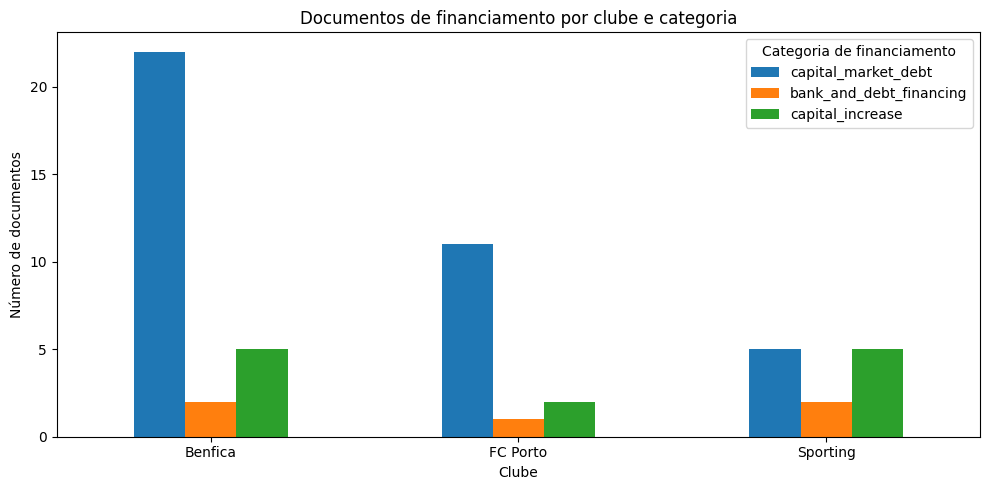

In [131]:
# =====================================================================
# 10.3 — Q1: documentos por clube e categoria
# =====================================================================

q1_base = relevantes.drop_duplicates(
    subset=[
        "doc_id",
        "clube",
        "tipo_evento_analise",
    ]
).copy()

# Define the categories to be displayed, excluding 'other_or_unclear' and 'multiple_or_ambiguous'
CATEGORIAS_FINANCIAMENTO_DISPLAY = [
    cat for cat in CATEGORIAS_FINANCIAMENTO
    if cat not in ['other_or_unclear', 'multiple_or_ambiguous']
]

q1_tabela = pd.crosstab(
    q1_base["clube"],
    q1_base["tipo_evento_analise"],
).reindex(
    index=["Benfica", "FC Porto", "Sporting"],
    columns=CATEGORIAS_FINANCIAMENTO_DISPLAY, # Use the filtered list here
    fill_value=0,
)

q1_tabela["Total"] = q1_tabela.sum(axis=1)
q1_tabela.loc["Total"] = q1_tabela.sum(axis=0)

q1_percentagens = (
    q1_tabela.iloc[:-1, :-1]
    .div(
        q1_tabela.iloc[:-1, -1].replace(
            0,
            np.nan,
        ),
        axis=0,
    )
    .mul(100)
    .round(1)
)

print("Q1 — Número de documentos por clube e categoria:")
display(q1_tabela)

print("Q1 — Distribuição percentual dentro de cada clube:")
display(q1_percentagens)

q1_tabela.to_csv(
    f"{PASTA_RESULTADOS}/q1_documentos_por_clube_categoria.csv",
    encoding="utf-8-sig",
)
q1_percentagens.to_csv(
    f"{PASTA_RESULTADOS}/q1_percentagens_por_clube.csv",
    encoding="utf-8-sig",
)

ax = q1_tabela.iloc[:-1, :-1].plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_title(
    "Documentos de financiamento por clube e categoria"
)
ax.set_xlabel("Clube")
ax.set_ylabel("Número de documentos")
ax.legend(title="Categoria de financiamento")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"{PASTA_RESULTADOS}/q1_documentos_por_clube_categoria.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [132]:
import pandas as pd
import os

# Construct the full path to the CSV file
caminho_q1_tabela = os.path.join(PASTA_RESULTADOS, "q1_documentos_por_clube_categoria.csv")

# Check if the file exists before attempting to read it
if os.path.exists(caminho_q1_tabela):
    q1_tabela_from_file = pd.read_csv(caminho_q1_tabela, index_col='clube')
    print("Conteúdo do ficheiro 'q1_documentos_por_clube_categoria.csv':")
    display(q1_tabela_from_file)
else:
    print(f"O ficheiro {caminho_q1_tabela} não foi encontrado.")


Conteúdo do ficheiro 'q1_documentos_por_clube_categoria.csv':


,capital_market_debt,bank_and_debt_financing,capital_increase,Total
clube,,,,
Benfica,22,2,5,29
FC Porto,11,1,2,14
Sporting,5,2,5,12
Total,38,5,12,55


### 10.3.1 — Human audit of the rule-based financing category

This comparison is restricted to human-confirmed positive documents with a valid human financing category. It evaluates the rule layer separately from the binary relevance classifier.

In [133]:
from sklearn.metrics import classification_report, confusion_matrix

categorias_validas = {
    "capital_market_debt",
    "bank_and_debt_financing",
    "capital_increase",
}

auditoria_tipo = (
    dados_modelo.loc[
        dados_modelo["relevante"].eq(1)
        & dados_modelo["tipo_evento"].isin(categorias_validas),
        ["doc_id", "tipo_evento"],
    ]
    .merge(
        corpus[
            [
                "doc_id",
                "tipo_evento_previsto",
            ]
        ],
        on="doc_id",
        how="inner",
        validate="one_to_one",
    )
)

print(
    "Positivos humanos disponíveis para avaliar a regra:",
    len(auditoria_tipo),
)

if not auditoria_tipo.empty:
    display(
        pd.crosstab(
            auditoria_tipo["tipo_evento"],
            auditoria_tipo["tipo_evento_previsto"],
            rownames=["humano"],
            colnames=["regra"],
        )
    )
    print(
        classification_report(
            auditoria_tipo["tipo_evento"],
            auditoria_tipo["tipo_evento_previsto"],
            labels=sorted(categorias_validas),
            zero_division=0,
        )
    )
else:
    print(
        "Ainda não existem positivos humanos categorizados "
        "suficientes para esta avaliação."
    )

Positivos humanos disponíveis para avaliar a regra: 12


regra,capital_market_debt,other_or_unclear
humano,,
bank_and_debt_financing,1,2
capital_increase,0,5
capital_market_debt,1,3


                         precision    recall  f1-score   support

bank_and_debt_financing       0.00      0.00      0.00         3
       capital_increase       0.00      0.00      0.00         5
    capital_market_debt       0.50      0.25      0.33         4

              micro avg       0.50      0.08      0.14        12
              macro avg       0.17      0.08      0.11        12
           weighted avg       0.17      0.08      0.11        12



## 10.4 — Q2: how are financing-related documents distributed over time?

The analysis uses the best available date for each document. Confirmed publication dates from URLs or article text are preferred; archive capture dates are used only as an explicit fallback and remain identifiable through `origem_data`. Peaks are descriptive and do not establish causality.

Documentos únicos por ano:


,documentos_unicos
ano,
2019,46
2020,75


Documentos por ano e clube:


clube,Benfica,FC Porto,Sporting
ano,,,
2019,26,5,21
2020,31,32,15


Documentos por ano e categoria:


tipo_evento_analise,capital_market_debt,bank_and_debt_financing,capital_increase
ano,,,
2019,7,3,12
2020,31,2,0


Origem das datas por ano:


origem_data,captura_arquivo,texto,url
ano,,,
2019,40,2,10
2020,53,21,4


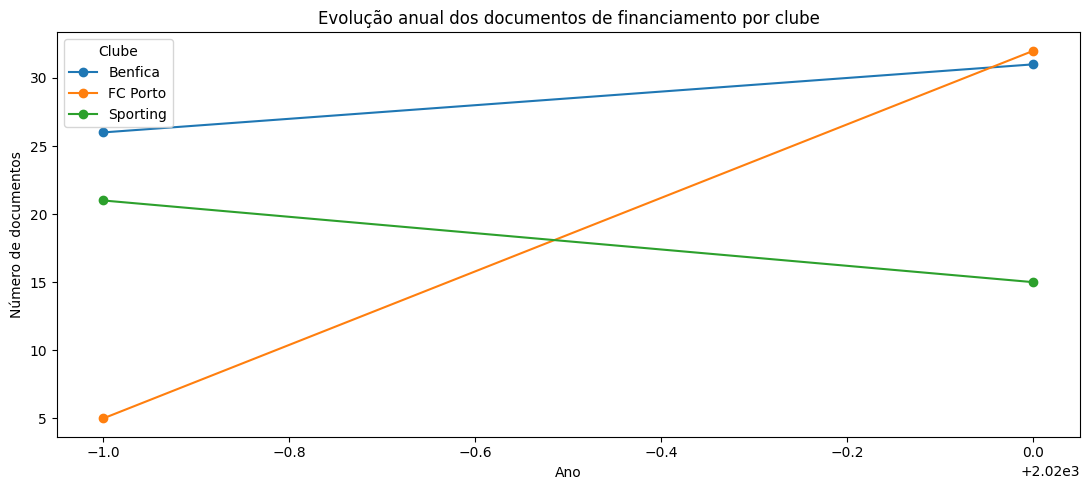

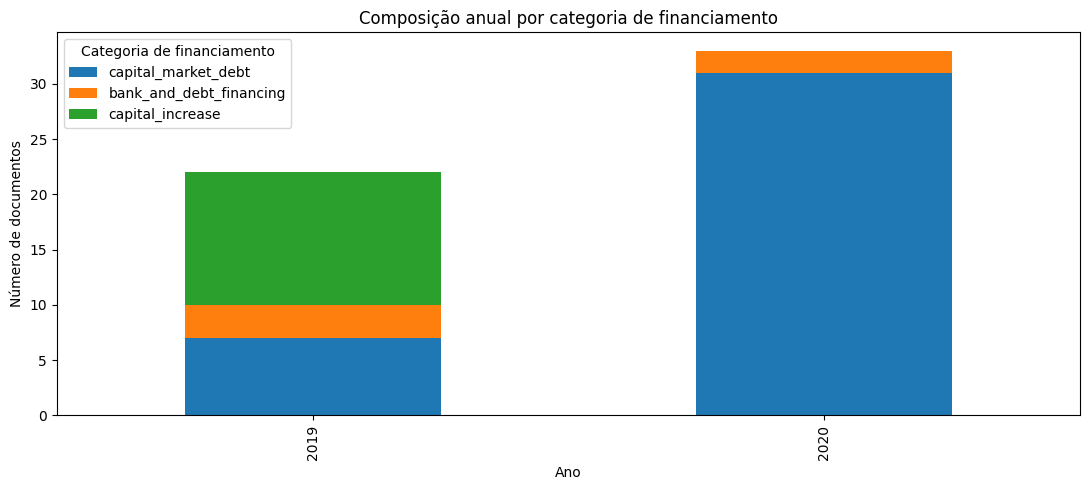

Anos acima da média mais um desvio-padrão (sinalização descritiva de concentração):


,documentos_unicos
ano,


In [134]:
# =====================================================================
# 10.4 — Q2: distribuição temporal dos documentos
# =====================================================================

q2_base = (
    relevantes
    .dropna(subset=["ano"])
    .drop_duplicates(
        subset=[
            "doc_id",
            "clube",
            "tipo_evento_analise",
        ]
    )
    .copy()
)
q2_base["ano"] = q2_base["ano"].astype(int)

q2_ano_clube = pd.crosstab(
    q2_base["ano"],
    q2_base["clube"],
).sort_index()

# Define the categories to be displayed, excluding 'other_or_unclear' and 'multiple_or_ambiguous'
CATEGORIAS_FINANCIAMENTO_DISPLAY = [
    cat for cat in CATEGORIAS_FINANCIAMENTO
    if cat not in ['other_or_unclear', 'multiple_or_ambiguous']
]

q2_ano_tipo = pd.crosstab(
    q2_base["ano"],
    q2_base["tipo_evento_analise"],
).reindex(
    columns=CATEGORIAS_FINANCIAMENTO_DISPLAY, # Use the filtered list here
    fill_value=0,
).sort_index()

q2_total_ano = (
    q2_base.groupby("ano")["doc_id"]
    .nunique()
    .rename("documentos_unicos")
    .to_frame()
)

print("Documentos únicos por ano:")
display(q2_total_ano)

print("Documentos por ano e clube:")
display(q2_ano_clube)

print("Documentos por ano e categoria:")
display(q2_ano_tipo)

if "origem_data" in q2_base.columns:
    q2_origem_data = pd.crosstab(
        q2_base["ano"],
        q2_base["origem_data"],
    ).sort_index()
    print("Origem das datas por ano:")
    display(q2_origem_data)
    q2_origem_data.to_csv(
        f"{PASTA_RESULTADOS}/q2_origem_datas_por_ano.csv",
        encoding="utf-8-sig",
    )

q2_total_ano.to_csv(
    f"{PASTA_RESULTADOS}/q2_documentos_por_ano.csv",
    encoding="utf-8-sig",
)
q2_ano_clube.to_csv(
    f"{PASTA_RESULTADOS}/q2_documentos_por_ano_clube.csv",
    encoding="utf-8-sig",
)
q2_ano_tipo.to_csv(
    f"{PASTA_RESULTADOS}/q2_documentos_por_ano_categoria.csv",
    encoding="utf-8-sig",
)

if not q2_ano_clube.empty:
    ax = q2_ano_clube.plot(
        marker="o",
        figsize=(11, 5),
    )
    ax.set_title(
        "Evolução anual dos documentos de financiamento por clube"
    )
    ax.set_xlabel("Ano")
    ax.set_ylabel("Número de documentos")
    ax.legend(title="Clube")
    plt.tight_layout()
    plt.savefig(
        f"{PASTA_RESULTADOS}/q2_evolucao_anual_clube.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

if not q2_ano_tipo.empty:
    ax = q2_ano_tipo.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 5),
    )
    ax.set_title(
        "Composição anual por categoria de financiamento"
    )
    ax.set_xlabel("Ano")
    ax.set_ylabel("Número de documentos")
    ax.legend(title="Categoria de financiamento")
    plt.tight_layout()
    plt.savefig(
        f"{PASTA_RESULTADOS}/q2_composicao_anual_tipo.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

if not q2_total_ano.empty:
    media = q2_total_ano["documentos_unicos"].mean()
    desvio = q2_total_ano["documentos_unicos"].std(ddof=0)
    limite_pico = media + desvio
    anos_pico = q2_total_ano.loc[
        q2_total_ano["documentos_unicos"] > limite_pico
    ]
    print(
        "Anos acima da média mais um desvio-padrão "
        "(sinalização descritiva de concentração):"
    )
    display(anos_pico)

## 10.5 — Q3: how much does coverage vary between clubs and sources?

Coverage is evaluated through unique archived documents, represented sources, years covered, and the proportion classified as relevant. Source diversity is encouraged during collection and annotation, but never imposed artificially: absent or sparse sources remain part of the empirical result.

Indicadores de cobertura por clube:


,noticias_unicas,fontes_unicas,primeiro_ano,ultimo_ano,anos_com_cobertura,noticias_relevantes,percentagem_relevante
clube,,,,,,,
Benfica,3289,7,2019,2020,2,57,1.7
FC Porto,1719,7,2019,2020,2,37,2.2
Sporting,2179,7,2019,2020,2,36,1.7


Distribuição por clube e fonte:


fonte,abola,maisfutebol,negocios,observador,ojogo,publico,record
clube,,,,,,,
Benfica,780,375,236,436,738,71,653
FC Porto,419,190,117,237,473,19,264
Sporting,831,331,147,200,420,22,228


Distribuição por ano e fonte:


fonte,abola,maisfutebol,negocios,observador,ojogo,publico,record
ano,,,,,,,
2019,738,241,250,582,810,49,517
2020,1292,655,250,291,821,63,628


Fontes observadas: ['abola', 'maisfutebol', 'negocios', 'observador', 'ojogo', 'publico', 'record']


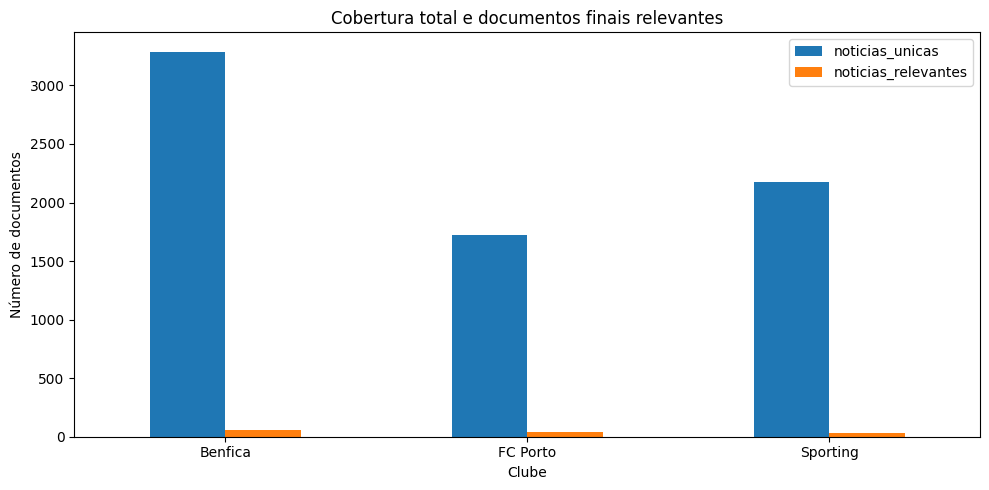

In [135]:
# =====================================================================
# 10.5 — Q3: cobertura e possível viés de fontes
# =====================================================================

cobertura_base = (
    analise_clube
    .drop_duplicates(
        subset=["doc_id", "clube"]
    )
    .copy()
)

q3_cobertura = (
    cobertura_base.groupby("clube")
    .agg(
        noticias_unicas=("doc_id", "nunique"),
        fontes_unicas=("fonte", "nunique"),
        primeiro_ano=("ano", "min"),
        ultimo_ano=("ano", "max"),
        anos_com_cobertura=("ano", "nunique"),
        noticias_relevantes=(
            "relevante_analise",
            lambda s: int((s == 1).sum()),
        ),
    )
    .reindex(["Benfica", "FC Porto", "Sporting"])
)

q3_cobertura["percentagem_relevante"] = (
    q3_cobertura["noticias_relevantes"]
    .div(
        q3_cobertura["noticias_unicas"]
        .replace(0, np.nan)
    )
    .mul(100)
    .round(1)
)

q3_fontes = pd.crosstab(
    cobertura_base["clube"],
    cobertura_base["fonte"],
).reindex(
    ["Benfica", "FC Porto", "Sporting"],
    fill_value=0,
)

q3_ano_fonte = pd.crosstab(
    cobertura_base["ano"],
    cobertura_base["fonte"],
).sort_index()

print("Indicadores de cobertura por clube:")
display(q3_cobertura)

print("Distribuição por clube e fonte:")
display(q3_fontes)

print("Distribuição por ano e fonte:")
display(q3_ano_fonte)

fontes_observadas = sorted(
    cobertura_base["fonte"]
    .dropna()
    .unique()
)
fontes_nao_observadas = sorted(
    set(FONTES_NOTICIOSAS)
    - set(fontes_observadas)
)
print("Fontes observadas:", fontes_observadas)
if fontes_nao_observadas:
    print(
        "Fontes configuradas sem cobertura utilizável:",
        fontes_nao_observadas,
    )

q3_cobertura.to_csv(
    f"{PASTA_RESULTADOS}/q3_indicadores_cobertura.csv",
    encoding="utf-8-sig",
)
q3_fontes.to_csv(
    f"{PASTA_RESULTADOS}/q3_cobertura_por_fonte.csv",
    encoding="utf-8-sig",
)
q3_ano_fonte.to_csv(
    f"{PASTA_RESULTADOS}/q3_cobertura_por_ano_fonte.csv",
    encoding="utf-8-sig",
)

if not q3_cobertura.empty:
    ax = q3_cobertura[
        ["noticias_unicas", "noticias_relevantes"]
    ].plot(
        kind="bar",
        figsize=(10, 5),
    )
    ax.set_title(
        "Cobertura total e documentos finais relevantes"
    )
    ax.set_xlabel("Clube")
    ax.set_ylabel("Número de documentos")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        f"{PASTA_RESULTADOS}/q3_cobertura_clubes.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 10.6 — Model quality and error analysis

This cell summarizes the untouched stratified 20% test results produced in Sections 7.4–7.7. These metrics evaluate binary relevance only; financing-category rules and information extraction require separate human evaluation.

In [136]:
# =====================================================================
# 10.6 — Qualidade do classificador binário
# =====================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

resumo_modelos = []

if all(nome in globals() for nome in ["y_teste", "y_previsto"]):
    precisao, recall, f1, _ = precision_recall_fscore_support(
        y_teste,
        y_previsto,
        average="binary",
        zero_division=0,
    )
    resumo_modelos.append({
        "modelo": "relevancia_binaria_tfidf_logreg",
        "n_teste": len(y_teste),
        "accuracy": accuracy_score(y_teste, y_previsto),
        "precision": precisao,
        "recall": recall,
        "f1": f1,
    })
else:
    print(
        "Avaliação binária indisponível: "
        "execute as Secções 7.4–7.7."
    )

resumo_modelos = pd.DataFrame(resumo_modelos)

if not resumo_modelos.empty:
    for coluna in ["accuracy", "precision", "recall", "f1"]:
        resumo_modelos[coluna] = resumo_modelos[coluna].round(3)
    display(resumo_modelos)
    resumo_modelos.to_csv(
        f"{PASTA_RESULTADOS}/resumo_modelos.csv",
        index=False,
        encoding="utf-8-sig",
    )

if "falsos_positivos_validacao" in globals():
    print(
        "Falsos positivos na validação:",
        len(falsos_positivos_validacao),
    )
if "falsos_negativos_validacao" in globals():
    print(
        "Falsos negativos na validação:",
        len(falsos_negativos_validacao),
    )

print(
    "A categorização do tipo de financiamento é rule-based "
    "e deve ser avaliada separadamente numa amostra humana."
)


,modelo,n_teste,accuracy,precision,recall,f1
0,relevancia_binaria_tfidf_logreg,41,0.902,0.667,0.4,0.5


Falsos positivos na validação: 1
Falsos negativos na validação: 3
A categorização do tipo de financiamento é rule-based e deve ser avaliada separadamente numa amostra humana.


## 10.7 — Descriptive synthesis

The following text is a descriptive synthesis generated from the tables. It should be reviewed before being used in the final report, especially when the number of annotated or validated examples is small.

In [137]:
# =====================================================================
# 10.7 — Síntese descritiva
# =====================================================================

linhas_sintese = []

if not q1_tabela.empty:
    totais_clube = q1_tabela.iloc[:-1]["Total"].sort_values(ascending=False)
    clube_maior = totais_clube.index[0]
    linhas_sintese.append(
        f"Q1: {clube_maior} apresentou o maior número de documentos classificados "
        f"({int(totais_clube.iloc[0])}), no conjunto analisado."
    )

    # Filter CATEGORIAS_FINANCIAMENTO to only include columns present in q1_tabela
    # This ensures that only existing columns are accessed, preventing KeyError.
    CATEGORIAS_FINANCIAMENTO_RESULTADOS = [
        cat for cat in CATEGORIAS_FINANCIAMENTO
        if cat not in ['other_or_unclear', 'multiple_or_ambiguous']
        and cat in q1_tabela.columns # Also check if present in the displayed q1_tabela
    ]

    totais_tipo = q1_tabela.loc["Total", CATEGORIAS_FINANCIAMENTO_RESULTADOS].sort_values(ascending=False)
    if not totais_tipo.empty: # Check if there are any types after filtering
        linhas_sintese.append(
            f"O tipo mais frequente foi {totais_tipo.index[0]} "
            f"({int(totais_tipo.iloc[0])} ocorrências documento–clube)."
        )
    else:
        linhas_sintese.append("Não foram encontrados tipos de evento de financiamento frequentes.")


if not q2_total_ano.empty:
    ano_max = int(q2_total_ano["documentos_unicos"].idxmax())
    valor_max = int(q2_total_ano.loc[ano_max, "documentos_unicos"])
    linhas_sintese.append(
        f"Q2: o maior número anual de documentos únicos ocorreu em {ano_max} "
        f"({valor_max}). Esta concentração é descritiva e não implica causalidade."
    )

if not q3_cobertura.empty:
    clube_cobertura = q3_cobertura["noticias_unicas"].idxmax()
    max_cobertura = int(q3_cobertura.loc[clube_cobertura, "noticias_unicas"])
    min_cobertura = int(q3_cobertura["noticias_unicas"].min())
    razao = max_cobertura / min_cobertura if min_cobertura else np.nan
    linhas_sintese.append(
        f"Q3: {clube_cobertura} teve a maior cobertura arquivada "
        f"({max_cobertura} notícias únicas). A razão entre a maior e a menor "
        f"cobertura foi {razao:.2f}, indicando que as comparações brutas "
        f"podem ser afetadas por disponibilidade desigual de fontes."
    )

for linha in linhas_sintese:
    print("•", linha)

with open(
    f"{PASTA_RESULTADOS}/sintese_resultados.txt",
    "w",
    encoding="utf-8",
) as ficheiro:
    ficheiro.write("\n".join(linhas_sintese))

• Q1: Benfica apresentou o maior número de documentos classificados (29), no conjunto analisado.
• O tipo mais frequente foi capital_market_debt (38 ocorrências documento–clube).
• Q2: o maior número anual de documentos únicos ocorreu em 2020 (75). Esta concentração é descritiva e não implica causalidade.
• Q3: Benfica teve a maior cobertura arquivada (3289 notícias únicas). A razão entre a maior e a menor cobertura foi 1.91, indicando que as comparações brutas podem ser afetadas por disponibilidade desigual de fontes.


## 10.8 — Limitations and interpretation criteria

- The observed unit is a **classified archived news document**, not necessarily a unique financing operation. Several documents may describe the same operation.
- Binary relevance metrics are valid only for the untouched, human-labelled, stratified 20% test set.
- The final corpus combines human decisions with model inference; every row records whether the relevance and category came from a human or an automatic component.
- Rule-based financing categories may miss paraphrases or assign `multiple_or_ambiguous`; their performance is audited separately on human-confirmed positives.
- spaCy entities and regex-extracted amounts, rates and dates are candidates and require contextual validation.
- Arquivo.pt availability varies by source, club and year. Higher document counts may reflect better archival coverage rather than more financing activity.
- Source diversity is actively encouraged but not imposed. Missing sources and years are reported as coverage limitations.
- Publication dates from URLs or article text are preferred. When neither is available, archive capture date is used only as an explicit fallback (`origem_data = captura_arquivo`), which weakens temporal interpretation.
- All analysis is restricted to the configured 2019–2020 window; 2026 is excluded because it is incomplete.
- Temporal peaks are descriptive and do not establish causality.
- News documents mentioning several clubs are counted once per club in comparative tables, while unique-document counts are also reported.
- Regulatory-document matching was excluded because corresponding primary documents could not be retrieved consistently for the selected news sample.

## 10.9 — Analysis outputs

The project execution creates:

| Location | File | Content |
|---|---|---|
| `v13/` | `config_fontes_aprovadas.json` | approved sources and advisory quality targets |
| `v13/` | `README_EXECUCAO.txt` | execution and folder instructions |
| `v13/raw/` | `club__source__year.jsonl` | resumable raw collection by club, source and year |
| `v13/logs/` | `auditoria_recolha.csv` | collection status and counts by club, source and year |
| `v13/anotacao/` | `para_anotar_template.csv` | blank diverse annotation template |
| `v13/anotacao/` | `para_anotar_humano.csv` | working human-annotation file |
| `v13/anotacao/` | `anotacoes_legadas_importadas.csv` | optional imported human labels |
| `v13/anotacao/` | `fila_revisao_modelo.csv` | uncertain unlabelled documents for active learning |
| `v13/resultados/` | `anotacoes_normalizadas_deduplicadas.csv` | cleaned human gold-standard labels |
| `v13/resultados/` | `dados_modelo_deduplicados.csv` | final supervised modelling dataset |
| `v13/resultados/` | `distribuicao_fontes_splits.csv` | stratified train/test source audit |
| `v13/resultados/` | `auditoria_origem_datas.csv` | confirmed and fallback date provenance |
| `v13/modelos/` | `modelo_relevancia.joblib` | final binary relevance model |
| `v13/` | `corpus_classificado.csv` | human-preserving full-corpus inference |

The notebook maximises diversity across available sources and reports shortfalls. It does not impose a mandatory source minimum or silently claim that coverage is representative.

---

## Research questions and final methods

**Q1 — How many financing-related archived documents were identified for each club, and how are they distributed across `capital_market_debt`, `bank_and_debt_financing`, and `capital_increase`?**

**Q2 — How are the relevant documents distributed between 2019 and 2025, and in which years are greater concentrations observed?**

**Q3 — How much does archival coverage vary between clubs, sources and years, and how may this affect comparisons?**

### Methods implemented in the project

| Step | Method | Evaluation/output |
|---|---|---|
| Collection | broad club queries plus focused financing queries, saved by club–source–year | resumable audit by source and year |
| Date policy | URL or article-text publication date, with flagged archive-capture fallback | date-provenance audit |
| Text preparation | cleaning, canonical URLs and deduplication | corpus-quality checks |
| Candidate selection | focused financing-category regex patterns and diverse source/year sampling | sampling support only |
| Human annotation | positives, easy negatives and hard negatives | normalised and deduplicated gold-standard labels |
| Train/test design | stratified 80/20 split after document deduplication | class and source audit |
| Representation | TF-IDF with unigrams and bigrams | fitted on training data |
| Relevance | balanced logistic regression with moderate sample weights | precision, recall, F1 and confusion matrix on the untouched human-labelled test set |
| Full-corpus inference | human labels override model predictions; uncertain unlabelled cases enter a review queue | provenance-preserving classified corpus |
| Financing category | human category overrides transparent rule-based assignment | separate audit on human-confirmed positives |
| Entities | pretrained spaCy NER plus `EntityRuler` | entity-level sample evaluation |
| Financial fields | regex extraction of amounts, rates and dates | field-level sample evaluation |
| Final analysis | tables, coverage indicators and annual series | answers to Q1–Q3 |

Custom NER training, supervised multiclass financing-category classification, full-scale PDF extraction/OCR, automatic news–regulatory-document matching, RAG and summarization remain future work.

```mermaid
graph TD
 A[Arquivo.pt: 2019–2025] --> B[Resumable collection by club, source and year]
 B --> C[Cleaning, date provenance and deduplication]
 C --> D[Diverse human annotation and label normalization]
 D --> E[Stratified 80/20 TF-IDF + Logistic Regression]
 E --> F[Human-preserving inference and active review queue]
 F --> G[Human-first financing category + rule fallback]
 G --> H[spaCy NER + regex extraction]
 H --> I[Coverage, timeline and document explorer]
```